<div style="text-align: center; background: #000; padding: 20px 10px; border-radius: 15px; box-shadow: 0 10px 25px rgba(0,0,0,0.7); font-family: 'Segoe UI', sans-serif; color: white;">

  <div style="position: relative; width: 100%; margin: 0 auto 10px auto;">

<img src="https://i.postimg.cc/QtK78P7J/images.jpg" 
     alt="Water Potability"
     style="
     display: block;
     width: 100%;
     height: auto;
     border-radius: 10px;
     box-shadow: 0 0 10px #666;
     ">


  </div>

</div>

[1. Metadata](#1)<br>
[2. Exploratory Data Analysis](#2)<br>
[3. Data Visualization](#3)<br>
[4. Data Cleaning & Feature Engineering](#4)<br>
[5. Linear Regression](#5)<br>
[6. Weather Groups — Does Removing the Weather Labels Matter?](#6)<br>

In [1]:
import os
import pandas as pd
import numpy as np
#from ydata_profiling import ProfileReport
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Traffic = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")
Traffic = pd.DataFrame(Traffic)
Traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
Traffic.shape

(48204, 9)

In [4]:
Traffic.info()

<class 'pandas.DataFrame'>
,RangeIndex: 48204 entries, 0 to 48203
,Data columns (total 9 columns):
, #   Column               Non-Null Count  Dtype  
,---  ------               --------------  -----  
, 0   holiday              61 non-null     str    
, 1   temp                 48204 non-null  float64
, 2   rain_1h              48204 non-null  float64
, 3   snow_1h              48204 non-null  float64
, 4   clouds_all           48204 non-null  int64  
, 5   weather_main         48204 non-null  str    
, 6   weather_description  48204 non-null  str    
, 7   date_time            48204 non-null  str    
, 8   traffic_volume       48204 non-null  int64  
,dtypes: float64(3), int64(2), str(4)
,memory usage: 5.0 MB


In [5]:
Traffic.duplicated().sum()

np.int64(17)

In [6]:
Traffic = Traffic.drop_duplicates()
Traffic.shape

(48187, 9)

<a id="1"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Metadata
  </h2>

</div>

In [7]:
#profile_Traffic = ProfileReport(
 #   Traffic, title = "Metro Interstate Traffic Volume"
  #  )

#profile_Traffic.to_file("Metro Interstate Traffic Volume.html")

#profile_Traffic

<div style="
    background: #eef2f7;
    padding: 25px;
    border-radius: 15px;
    box-shadow: 0 6px 18px rgba(0,0,0,0.18);
    font-family: 'Segoe UI', sans-serif;
    color: #1f2937;
">

<h2 style="
    text-align: center;
    color: #1e3a5f;
    margin: 0 0 22px 0;
    font-family: Georgia, 'Times New Roman', serif;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.12);
">
    Metro Interstate Traffic Volume — Feature Metadata
</h2>

<div style="
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 14px;
">

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">holiday</div>
    <div style="color:#374151;">Indicates whether the observation occurred on a U.S. national holiday or during the Minnesota State Fair.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">temp</div>
    <div style="color:#374151;">Average temperature recorded at the time of observation, measured in Kelvin.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">rain_1h</div>
    <div style="color:#374151;">Amount of rainfall recorded during the previous hour, measured in millimeters.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">snow_1h</div>
    <div style="color:#374151;">Amount of snowfall recorded during the previous hour, measured in millimeters.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">clouds_all</div>
    <div style="color:#374151;">Percentage of cloud cover recorded at the time of observation.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">weather_main</div>
    <div style="color:#374151;">Short textual description of the prevailing weather condition.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">weather_description</div>
    <div style="color:#374151;">Detailed textual description of the prevailing weather condition.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">date_time</div>
    <div style="color:#374151;">Date and hour when the observation was recorded in local Central Standard Time (CST).</div>
</div>

<div style="
    background:#f4f7fb;
    border:1px solid #aebdce;
    border-left:5px solid #1e3a5f;
    border-radius:8px;
    padding:14px 18px;
    box-shadow:0 2px 6px rgba(0,0,0,0.08);
">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">traffic_volume</div>
    <div style="color:#374151;">Hourly westbound traffic volume on Interstate 94 (I-94), recorded by ATR Station 301.</div>
</div>

</div>
</div>

<a id="2"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Exploratory Data Analysis
  </h2>

</div>

In [8]:
Traffic['date_time'] = pd.to_datetime(Traffic['date_time'])


# ============================================================
# 1. Replace NaN values with U.S. federal holidays
# ============================================================

cal = USFederalHolidayCalendar()

holiday_mapping = {}

for rule in cal.rules:
    dates = rule.dates(
        Traffic['date_time'].min(),
        Traffic['date_time'].max()
    )

    for date in dates:
        holiday_mapping[date.normalize()] = rule.name


# Standardize holiday names
name_mapping = {
    "New Year's Day": "New Years Day",
    "Birthday of Martin Luther King, Jr.": "Martin Luther King Jr Day",
    "Washington's Birthday": "Washingtons Birthday"
}

holiday_mapping = {
    date: name_mapping.get(name, name)
    for date, name in holiday_mapping.items()
}


# Replace only NaN values that fall on federal holidays
mask_h = Traffic['holiday'].isna()

holiday_names = (
    Traffic.loc[mask_h, 'date_time']
    .dt.normalize()
    .map(holiday_mapping)
)

Traffic.loc[mask_h & holiday_names.notna(), 'holiday'] = (
    holiday_names.dropna().values
)

In [9]:
# ============================================================
# 2. Replace remaining NaN values with Minnesota State Fair
# ============================================================

state_fair_dates = pd.to_datetime([
    '2013-08-22',
    '2015-08-27',
    '2016-08-25',
    '2017-08-24',
    '2018-08-23'
])


mask_s = (
    Traffic['holiday'].isna() &
    Traffic['date_time'].dt.normalize().isin(state_fair_dates)
)

Traffic.loc[mask_s, 'holiday'] = 'State Fair'

In [10]:
# ============================================================
# 3. Label remaining NaN values
# ============================================================

Traffic.loc[
    Traffic['holiday'].isna(),
    'holiday'
] = 'Not Holiday'

In [11]:
Traffic['date_time'] = pd.to_datetime(Traffic['date_time'])

Traffic['year'] =Traffic['date_time'].dt.year
Traffic['month'] = Traffic['date_time'].dt.month
Traffic['day'] = Traffic['date_time'].dt.day
Traffic['hour'] = Traffic['date_time'].dt.hour
Traffic = Traffic.drop(columns=['date_time'])

Traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour
0,Not Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,2012,10,2,9
1,Not Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,4516,2012,10,2,10
2,Not Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,2012,10,2,11
3,Not Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,2012,10,2,12
4,Not Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,4918,2012,10,2,13


In [12]:
summary = pd.DataFrame({
    "Description": [
        "Number of variables",
        "Number of observations",
        "Number of categorical variables",
        "Number of continuous variables"
    ],
    "Value": [
        Traffic.shape[1],
        Traffic.shape[0],
        Traffic.select_dtypes(include="object").shape[1],
        Traffic.select_dtypes(include=["int", "float64"]).shape[1]
    ]
})

summary

/tmp/ipykernel_11421/3792786768.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
,See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
,  Traffic.select_dtypes(include="object").shape[1],


,Description,Value
0,Number of variables,12
1,Number of observations,48187
2,Number of categorical variables,3
3,Number of continuous variables,9


In [13]:
cat_vars = ['holiday','weather_main','weather_description']
con_vars = ['temp','rain_1h','snow_1h','clouds_all','year','month','day','hour','traffic_volume']

In [14]:
for col in cat_vars:
    print(
        f"Feature: {col} \n"
        f"Number of unique values: {Traffic[col].nunique()}\n"
        f"Unique values: {Traffic[col].unique()}"
)
    
    print("-"*120)

Feature: holiday 
,Number of unique values: 12
,Unique values: <ArrowStringArray>
,[              'Not Holiday',              'Columbus Day',
,              'Veterans Day',          'Thanksgiving Day',
,             'Christmas Day',             'New Years Day',
, 'Martin Luther King Jr Day',      'Washingtons Birthday',
,              'Memorial Day',          'Independence Day',
,                'State Fair',                 'Labor Day']
,Length: 12, dtype: str
,------------------------------------------------------------------------------------------------------------------------
,Feature: weather_main 
,Number of unique values: 11
,Unique values: <ArrowStringArray>
,[      'Clouds',        'Clear',         'Rain',      'Drizzle',
,         'Mist',         'Haze',          'Fog', 'Thunderstorm',
,         'Snow',       'Squall',        'Smoke']
,Length: 11, dtype: str
,---------------------------------------------------------------------------------------------------------------------

In [15]:
for var in cat_vars:
    print(f"\n{var}")
    print(Traffic[var].value_counts())
    print("-"*80)


,holiday
,holiday
,Not Holiday                  46723
,Labor Day                      157
,Independence Day               146
,Martin Luther King Jr Day      142
,Washingtons Birthday           136
,Thanksgiving Day               135
,Memorial Day                   134
,Christmas Day                  131
,New Years Day                  131
,Veterans Day                   120
,State Fair                     120
,Columbus Day                   112
,Name: count, dtype: int64
,--------------------------------------------------------------------------------
,
,weather_main
,weather_main
,Clouds          15158
,Clear           13384
,Mist             5949
,Rain             5672
,Snow             2875
,Drizzle          1820
,Haze             1360
,Thunderstorm     1033
,Fog               912
,Smoke              20
,Squall              4
,Name: count, dtype: int64
,--------------------------------------------------------------------------------
,
,weather_description
,weather_description
,sky

In [16]:
Traffic[con_vars].describe()

,temp,rain_1h,snow_1h,clouds_all,year,month,day,hour,traffic_volume
count,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000
mean,281.204995,0.334382,0.000222,49.365451,2015.512047,6.505240,15.736402,11.397742,3259.618134
std,13.338738,44.797033,0.008169,39.015213,1.893393,3.400285,8.721687,6.940373,1986.954465
min,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014.000000,4.000000,8.000000,5.000000,1192.500000
50%,282.450000,0.000000,0.000000,64.000000,2016.000000,7.000000,16.000000,11.000000,3379.000000
75%,291.806000,0.000000,0.000000,90.000000,2017.000000,9.000000,23.000000,17.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018.000000,12.000000,31.000000,23.000000,7280.000000


<a id="3"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Data Visualization
  </h2>

</div>

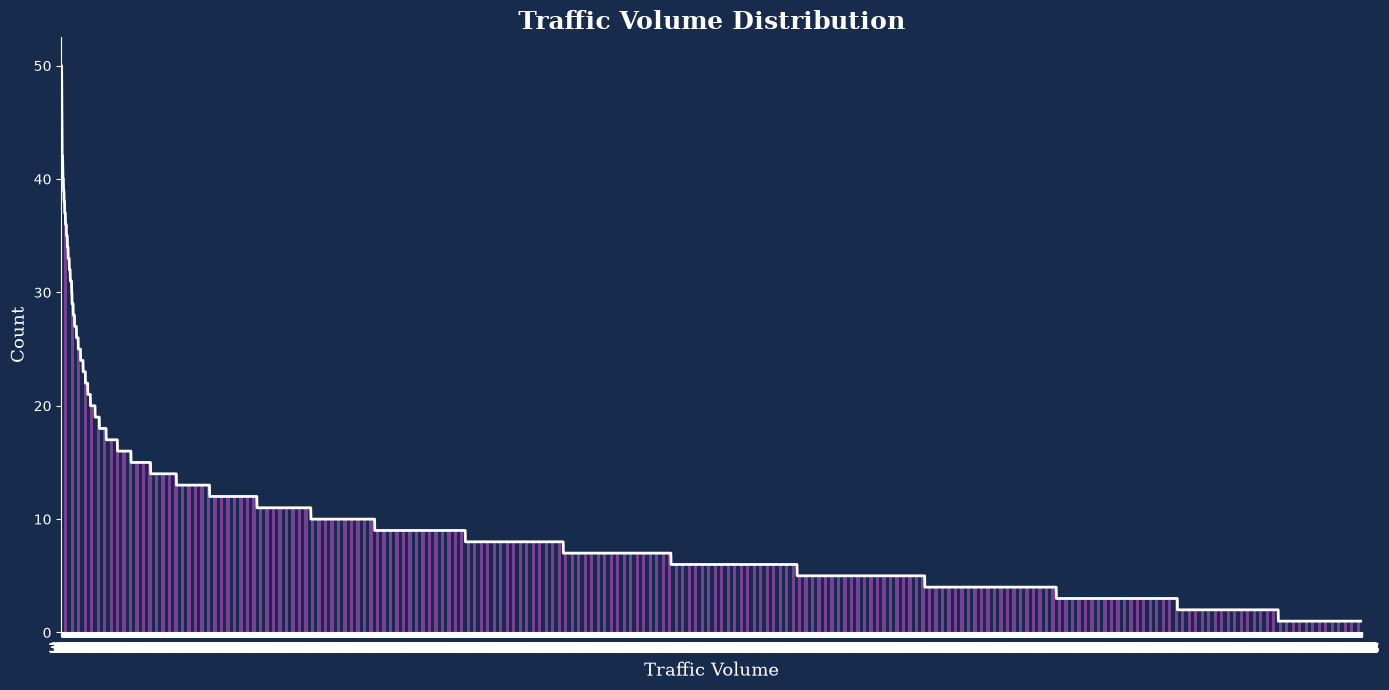

In [17]:
counts = Traffic['traffic_volume'].value_counts()

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#172B4D')
ax.set_facecolor('#172B4D')

counts.plot(
    kind='bar',
    ax=ax,
    color="#7B3F98"
)

plt.plot(
    range(len(counts)),
    counts.values,
    color='white',
    linewidth=2
)

plt.xlabel(
    'Traffic Volume',
    fontsize=13,
    fontfamily='serif',
    color='white'
)

plt.ylabel(
    'Count',
    fontsize=13,
    fontfamily='serif',
    color='white'
)

plt.title(
    'Traffic Volume Distribution',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
    color='white'
)

plt.xticks(rotation=0, color='white')
plt.yticks(color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()

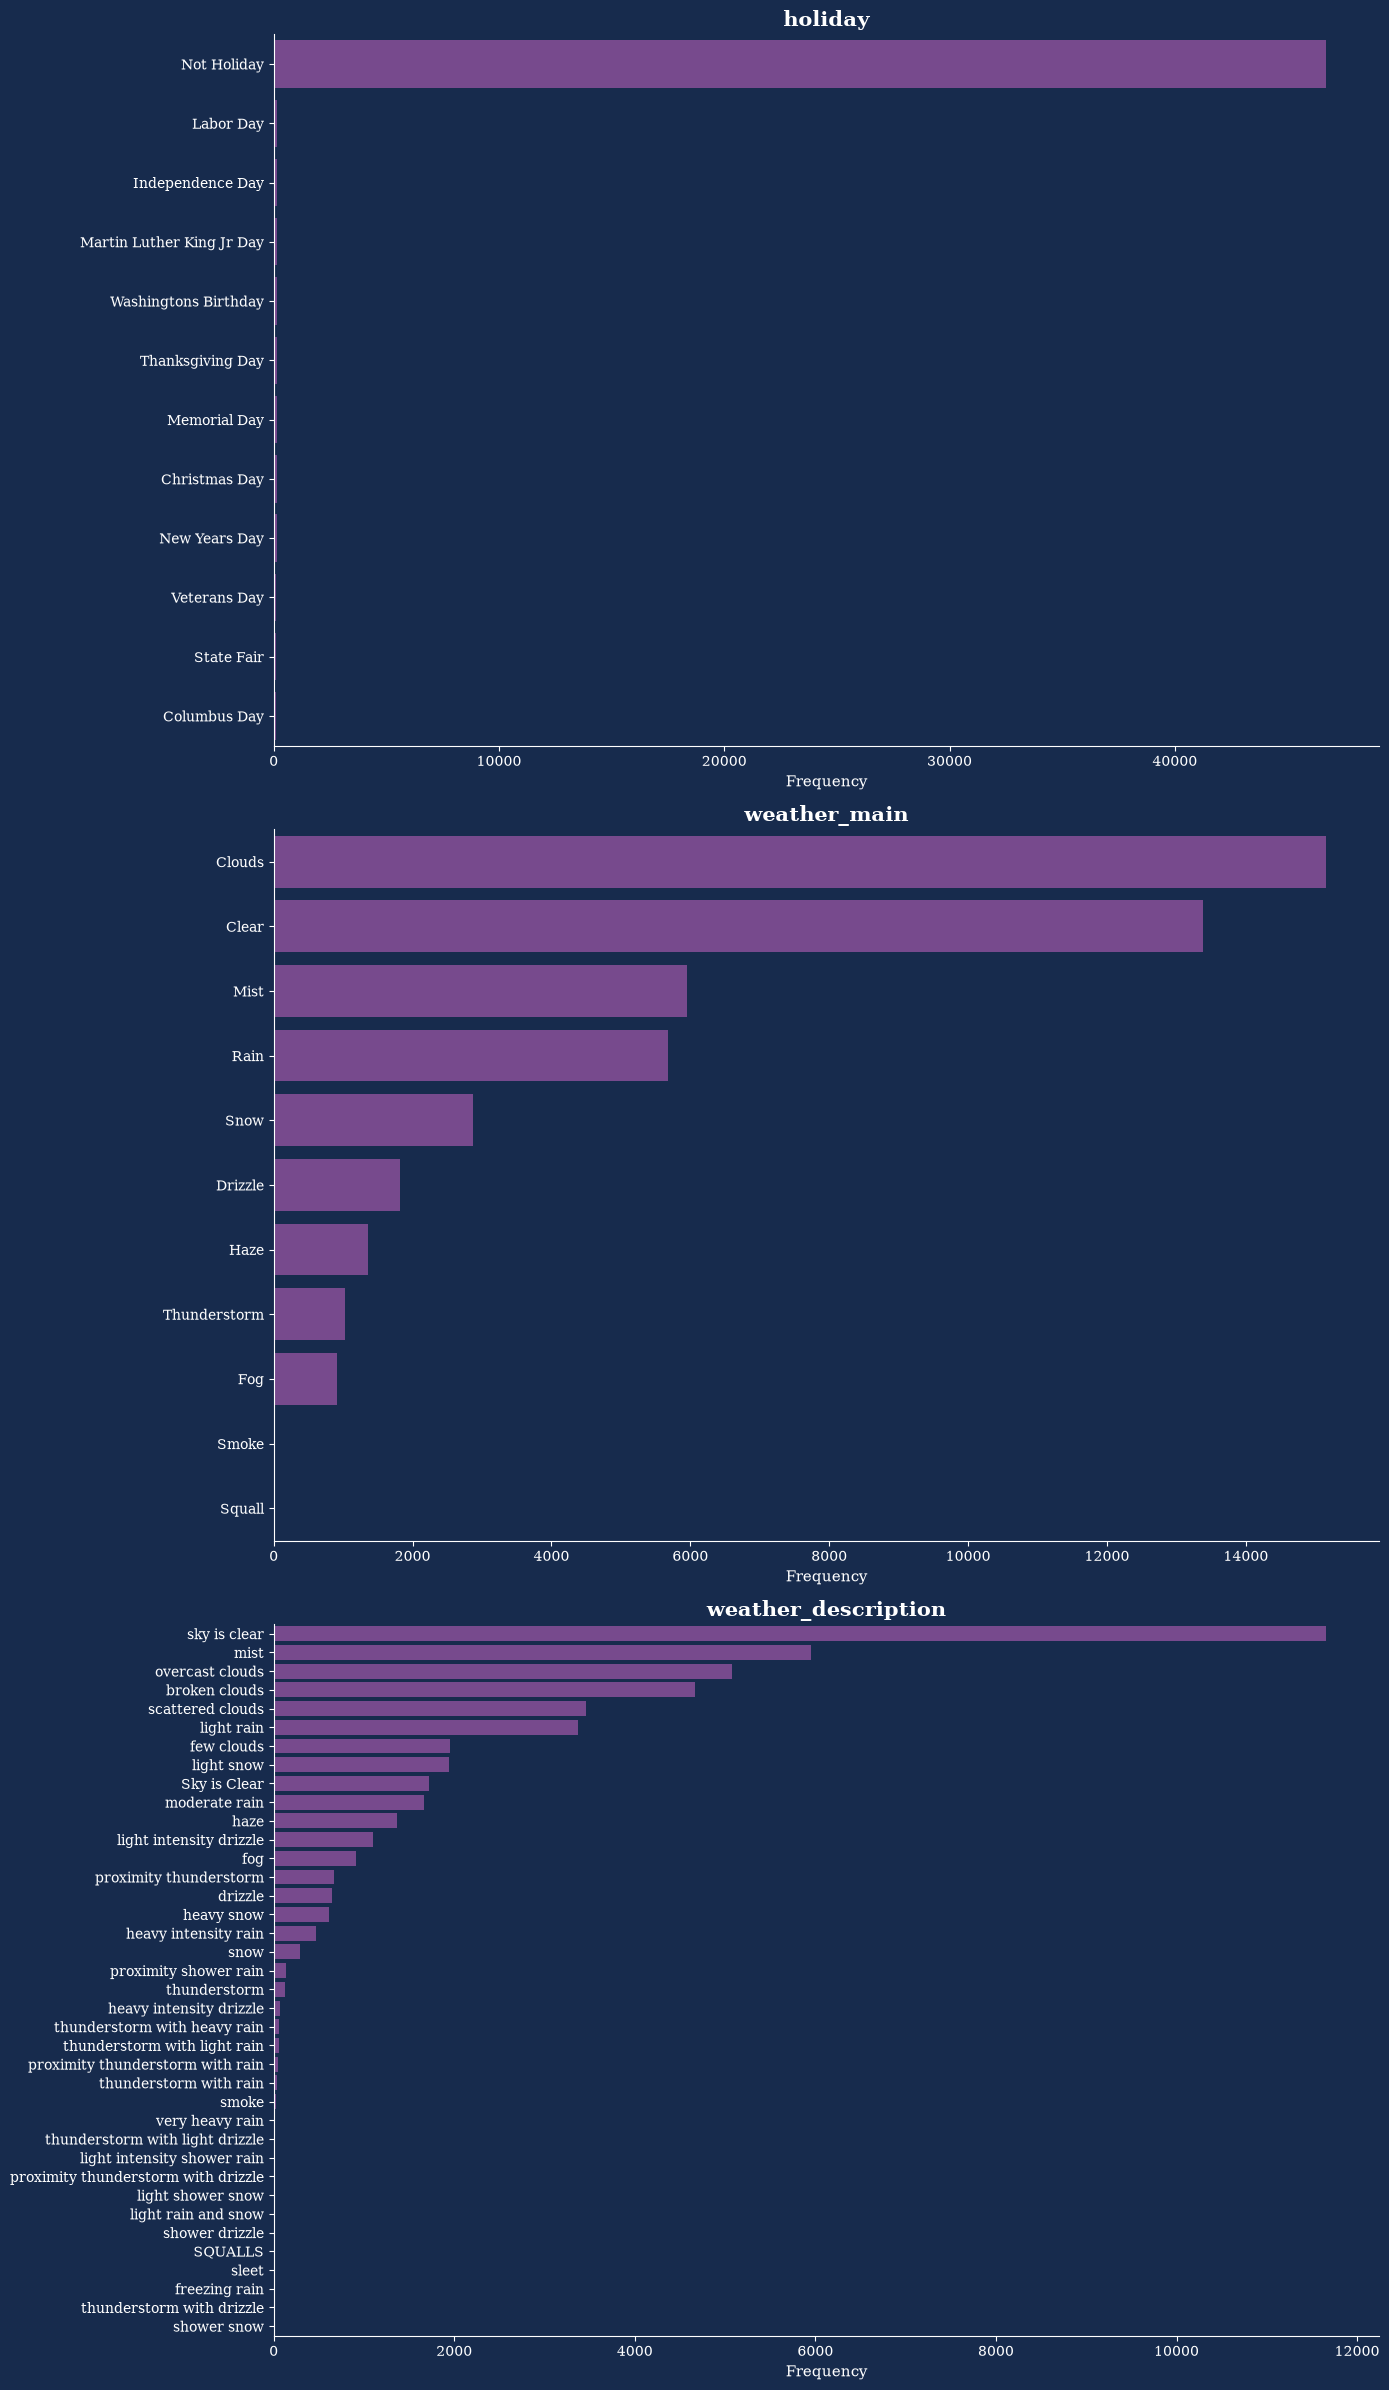

In [18]:
fig, axes = plt.subplots(
    nrows=len(cat_vars),
    ncols=1,
    figsize=(14, 8 * len(cat_vars)),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes)

for i, var in enumerate(cat_vars):

    counts = Traffic[var].value_counts()

    axes[i].set_facecolor("#172B4D")

    sns.barplot(
        x=counts.values,
        y=counts.index,
        ax=axes[i],
        color="#7B3F98"
    )

    axes[i].set_title(
        var,
        fontsize=15,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    axes[i].set_xlabel(
        'Frequency',
        fontsize=11,
        fontfamily='serif',
        color='white'
    )

    axes[i].set_ylabel('')

    axes[i].tick_params(
        axis='both',
        colors='white'
    )

    # Serif font for tick labels
    for label in axes[i].get_xticklabels():
        label.set_fontfamily('serif')

    for label in axes[i].get_yticklabels():
        label.set_fontfamily('serif')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('white')
    axes[i].spines['bottom'].set_color('white')


plt.tight_layout()
plt.show()

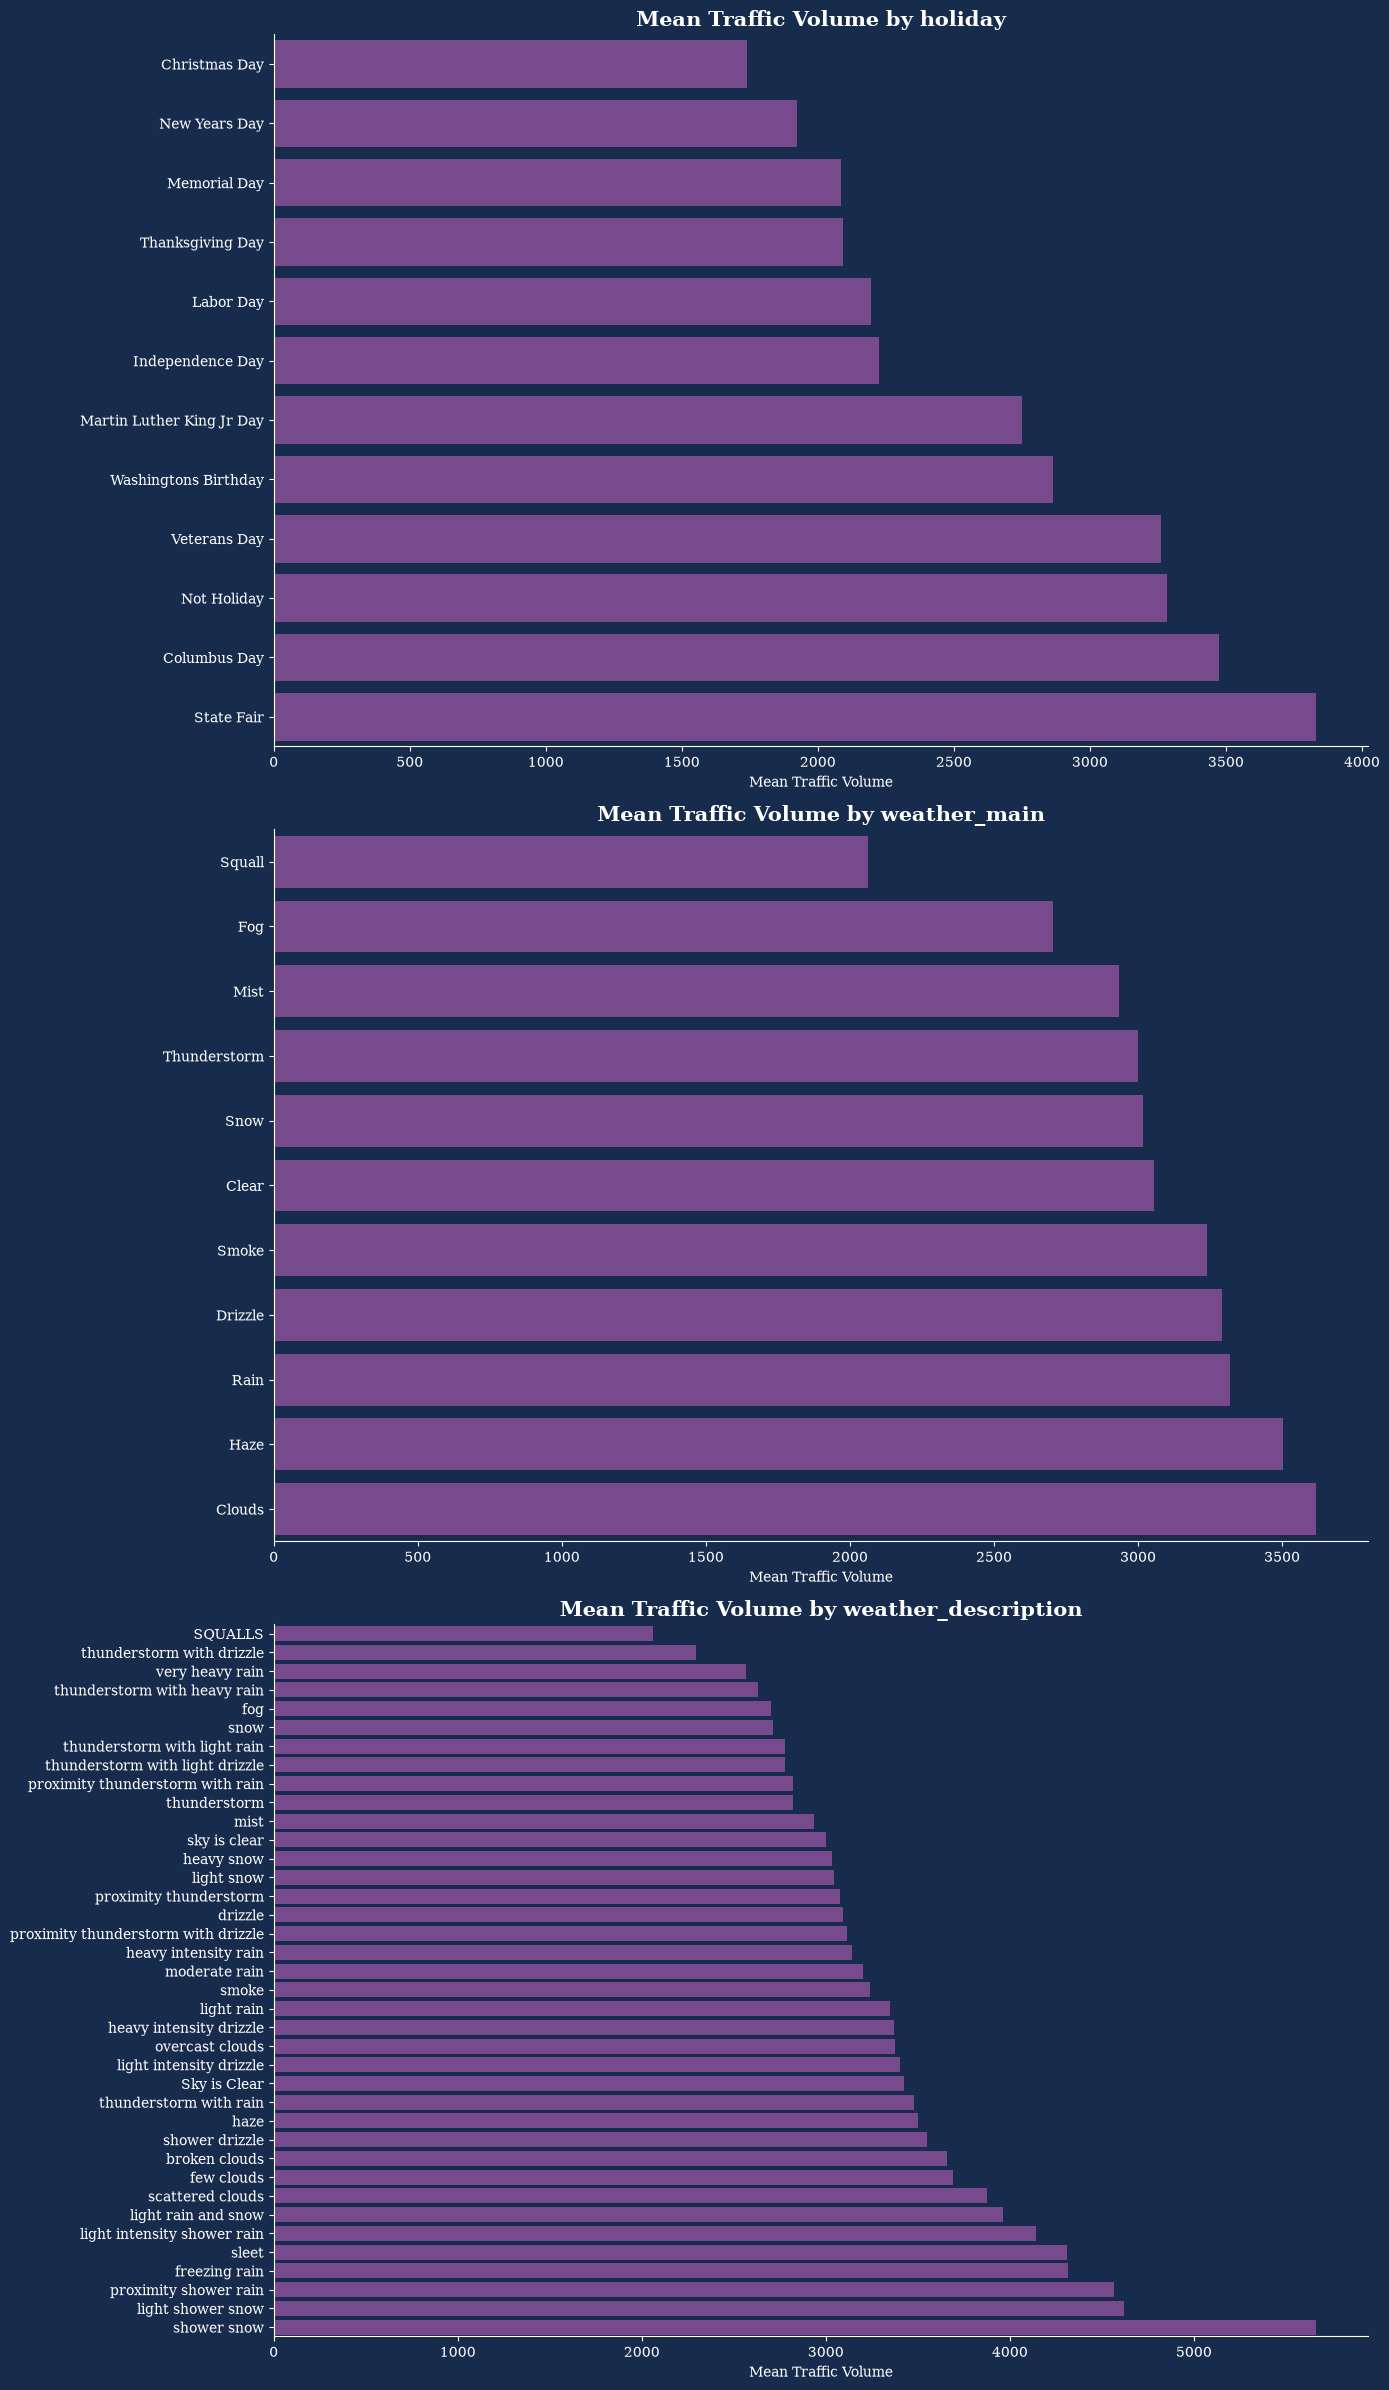

In [19]:
fig, axes = plt.subplots(
    nrows=len(cat_vars),
    ncols=1,
    figsize=(14, 8 * len(cat_vars)),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes)

for i, var in enumerate(cat_vars):

    mean_traffic = Traffic.groupby(var)['traffic_volume'].mean().sort_values()

    axes[i].set_facecolor("#172B4D")

    sns.barplot(
        x=mean_traffic.values,
        y=mean_traffic.index,
        ax=axes[i],
        color="#7B3F98"
    )

    axes[i].set_title(
        f'Mean Traffic Volume by {var}',
        fontsize=15,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    axes[i].set_xlabel(
        'Mean Traffic Volume',
        fontsize=10,
        fontfamily='serif',
        color='white'
    )

    axes[i].set_ylabel('')

    axes[i].tick_params(
        axis='both',
        colors='white'
    )

    for label in axes[i].get_xticklabels():
        label.set_fontfamily('serif')

    for label in axes[i].get_yticklabels():
        label.set_fontfamily('serif')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('white')
    axes[i].spines['bottom'].set_color('white')


plt.tight_layout()
plt.show()

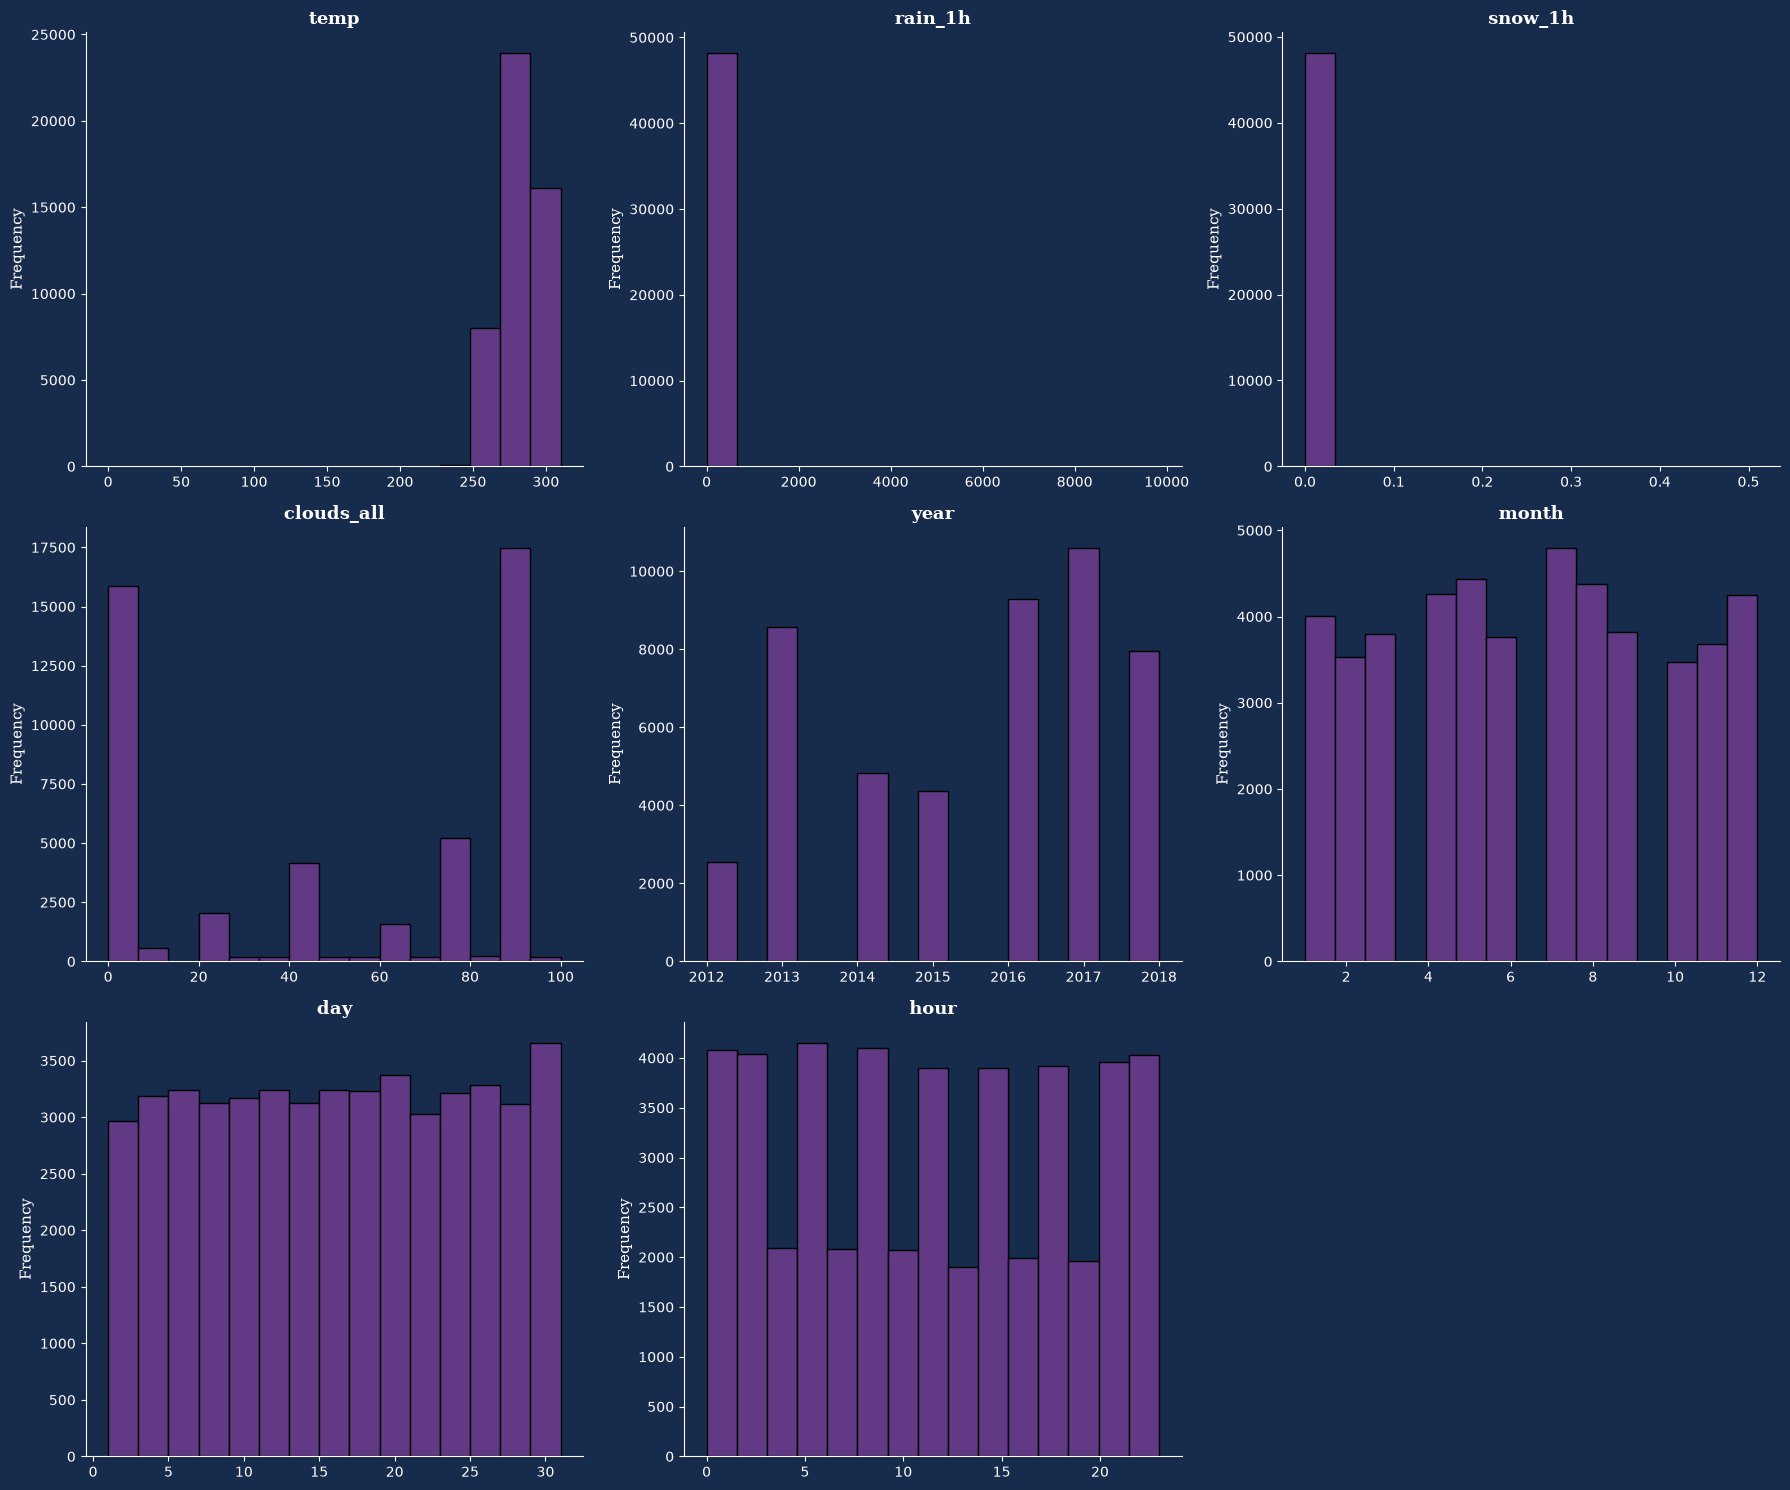

In [20]:
con_vars_ = [var for var in con_vars if var != 'traffic_volume']

n = len(con_vars_)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes).flatten()

for i, var in enumerate(con_vars_):

    ax = axes[i]
    ax.set_facecolor("#172B4D")

    sns.histplot(
        data=Traffic,
        x=var,
        bins=15,
        ax=ax,
        color="#7B3F98"
    )

    # Set x-axis according to the actual range of each variable
    xmin = Traffic[var].min()
    xmax = Traffic[var].max()
    padding = (xmax - xmin) * 0.05

    ax.set_xlim(xmin - padding, xmax + padding)

    ax.set_title(
        var,
        fontsize=13,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    ax.set_xlabel('')
    ax.set_ylabel(
        'Frequency',
        fontsize=11,
        fontfamily='serif',
        color='white'
    )

    ax.tick_params(axis='both', colors='white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

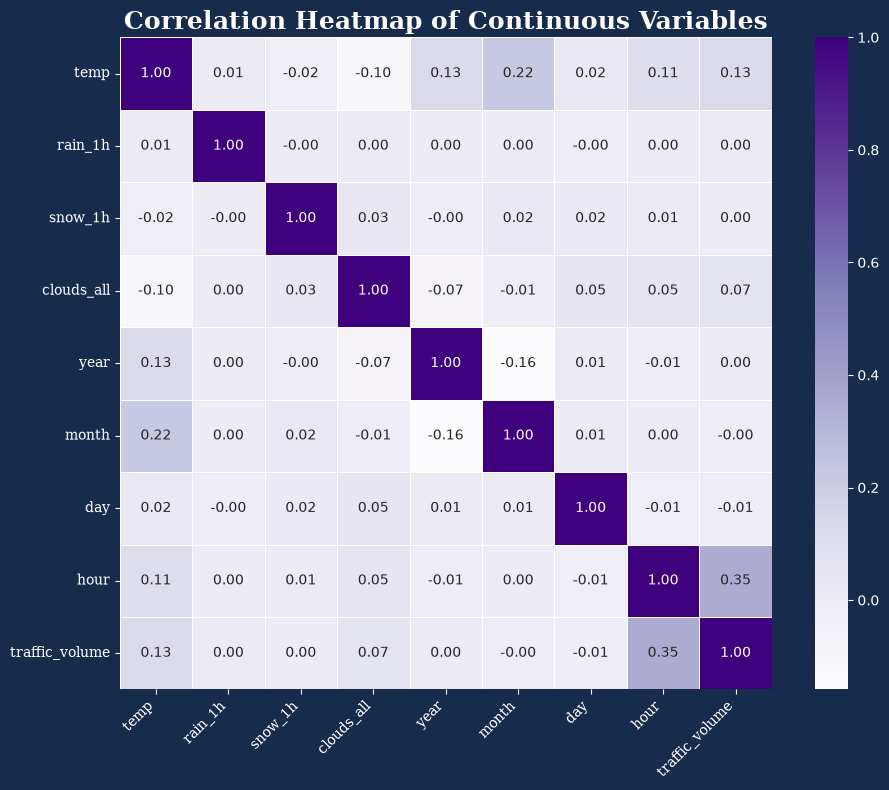

In [21]:
corr = Traffic[con_vars].corr()

plt.figure(figsize=(10, 8), facecolor="#172B4D")

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Purples',
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Continuous Variables',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
    color='white'
)

plt.xticks(
    fontfamily='serif',
    color='white',
    rotation=45,
    ha='right'
)

plt.yticks(
    fontfamily='serif',
    color='white',
    rotation=0
)

plt.tight_layout()
plt.show()

<a id="4"></a>
<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 0 0 14px 0;"><h2 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">Data Cleaning &amp; Feature Engineering</h2></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">4.1 — Getting Started</h3></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">This section continues from the <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Traffic</code> DataFrame built in the EDA section above, so nothing the EDA already did is repeated here:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>Exact duplicate rows</b> were already removed there (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">drop_duplicates()</code>); an assertion in 4.3.1 confirms the count.</li><li style="margin-bottom:4px;"><b>Date parts</b>: <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">date_time</code> was already split into <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">month</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code>; those columns are reused instead of being extracted again.</li><li style="margin-bottom:4px;"><b>Holiday labels</b> were rebuilt there for exploration only. Holiday/event information is not part of the features in this section.</li></ul><p style="margin:0 0 8px 0;">A second, untouched read of the CSV (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">raw</code>) is loaded for one purpose only: the audit in 4.2 must describe the data <b>before any change</b>, and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Traffic</code> no longer qualifies (rows were dropped, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">holiday</code> was overwritten and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">date_time</code> was removed). No cleaning is ever applied to <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">raw</code>.</p><p style="margin:0 0 8px 0;"><b>Team decisions applied in this section:</b> the weather label columns (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_main</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_description</code>) and all holiday/event features are excluded from the features, and temperature is converted from Kelvin to °C.</p></div>

In [22]:
RAIN_MAX_PLAUSIBLE = 100.0     # mm/h; next-highest real value in the data is ~55 mm/h
LOW_VOLUME_THRESHOLD = 100     # vehicles/h
RUSH_HOURS = [6, 7, 8, 15, 16, 17]
INTERP_MAX_HOURS = 48          # max span (between valid neighbours) temperature interpolation may bridge
TEMP_SENTINELS = [276.793, 297.888]   # stuck / placeholder temperatures, in raw Kelvin (found in audit 4.2.4)
KELVIN_OFFSET = 273.15         # degrees C = K - 273.15

# Read-only baseline for the audit in 4.2 ("before any changes"); never cleaned.
raw = pd.read_csv('../data/Metro_Interstate_Traffic_Volume.csv', parse_dates=['date_time'])
print('raw shape:', raw.shape)

raw shape: (48204, 9)


In [23]:
# Chart theme: same palette and fonts as the EDA charts above
# (dark navy background, purple, white serif text, no top/right spines)
THEME_BG = '#172B4D'
THEME_PURPLE = '#7B3F98'
THEME_LAVENDER = '#D8D6FF'
THEME_ACCENT = '#F5B841'     # highlight colour for raw values / anomalies


def style_axes(ax, title=None, xlabel=None, ylabel=None, title_size=13):
    """Apply the notebook's dark theme to one axes."""
    ax.set_facecolor(THEME_BG)
    if title is not None:
        ax.set_title(title, fontsize=title_size, fontweight='bold', fontfamily='serif', color='white')
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=11, fontfamily='serif', color='white')
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=11, fontfamily='serif', color='white')
    ax.tick_params(axis='both', colors='white', labelfontfamily='serif')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')


def style_legend(ax, **kwargs):
    """Legend that matches the dark theme."""
    return ax.legend(frameon=False, labelcolor='white', prop={'family': 'serif', 'size': 9}, **kwargs)

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">4.2 — Data Quality Audit (Before Any Changes)</h3></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.1 — Missing Values</h4></div>

In [24]:
audit = pd.DataFrame({'dtype': raw.dtypes.astype(str),
                      'n_missing': raw.isna().sum(),
                      'missing_%': (raw.isna().mean() * 100).round(2),
                      'n_unique': raw.nunique()})
audit

,dtype,n_missing,missing_%,n_unique
holiday,str,48143,99.87,11
temp,float64,0,0.00,5843
rain_1h,float64,0,0.00,372
snow_1h,float64,0,0.00,12
clouds_all,int64,0,0.00,60
weather_main,str,0,0.00,11
weather_description,str,0,0.00,38
date_time,datetime64[us],0,0.00,40575
traffic_volume,int64,0,0.00,6704


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Only <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">holiday</code> has missing values (48,143 rows, 99.87 %). This is a <b>structural</b> absence meaning "no holiday/event on that day", not a lost measurement, so it must not be imputed with a mean/median. Holiday/event information is excluded from the features in this section (team decision), so the column is simply not carried forward.</p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.2 — Duplicate Rows: Two Distinct Types</h4></div>

In [25]:
n_exact = int(raw.duplicated().sum())
tmp = raw.drop_duplicates()
grp = tmp.groupby('date_time')
sizes = grp.size()

dup_report = pd.Series({
    'exact duplicate rows': n_exact,
    'rows after exact-dedup': len(tmp),
    'unique timestamps': sizes.size,
    'timestamps with >1 row': int((sizes > 1).sum()),
    'groups where traffic_volume differs': int((grp.traffic_volume.nunique() > 1).sum()),
    'groups where temp differs': int((grp.temp.nunique() > 1).sum()),
    'groups where rain_1h differs': int((grp.rain_1h.nunique() > 1).sum()),
    'groups where snow_1h differs': int((grp.snow_1h.nunique() > 1).sum()),
    'groups where clouds_all differs': int((grp.clouds_all.nunique() > 1).sum()),
    'groups where weather_main differs': int((grp.weather_main.nunique() > 1).sum()),
    'groups where weather_description differs': int((grp.weather_description.nunique() > 1).sum()),
})
print(dup_report.to_string())
print('\nlargest group example:')
tmp[tmp.date_time == sizes.idxmax()]

exact duplicate rows                           17
,rows after exact-dedup                      48187
,unique timestamps                           40575
,timestamps with >1 row                       5430
,groups where traffic_volume differs             0
,groups where temp differs                      78
,groups where rain_1h differs                    9
,groups where snow_1h differs                    0
,groups where clouds_all differs                32
,groups where weather_main differs            5349
,groups where weather_description differs     5386
,
,largest group example:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
5249,NaN,274.79,0.0,0.0,90,Mist,mist,2013-04-18 22:00:00,1532
5250,NaN,274.79,0.0,0.0,90,Drizzle,light intensity drizzle,2013-04-18 22:00:00,1532
5251,NaN,274.79,0.0,0.0,90,Rain,light rain,2013-04-18 22:00:00,1532
5252,NaN,274.79,0.0,0.0,90,Rain,moderate rain,2013-04-18 22:00:00,1532
5253,NaN,274.79,0.0,0.0,90,Snow,heavy snow,2013-04-18 22:00:00,1532
5254,NaN,274.79,0.0,0.0,90,Snow,snow,2013-04-18 22:00:00,1532


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;"><b>Result:</b> there are 17 completely duplicate rows (already dropped in the EDA section), but more importantly <b>thousands of timestamps still have more than one row</b> (5,430). Within these groups <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">traffic_volume</code> never varies and the numeric weather values are almost always identical; what varies are the <b>textual weather labels</b> (several weather reports recorded for a single hour). The correct treatment is therefore to aggregate into a single row per hour, and <b>the main challenge is selecting the weather label</b>, not the numeric values.</p><p style="margin:0 0 8px 0;"><b>Note:</b> <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">drop_duplicates()</code> alone (as done in the EDA section) is not enough: every hour with several reports is still counted several times, which skews EDA means and correlations toward high-frequency hours.</p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.3 — Physically Impossible Values</h4></div>

In [26]:
zero_k = raw[raw.temp <= 0]
print('rows with temp <= 0 K:', len(zero_k))
valid_c = raw.loc[raw.temp > 0, 'temp'] - KELVIN_OFFSET
print('valid temp range (°C): %.2f -> %.2f' % (valid_c.min(), valid_c.max()))
print(zero_k.groupby(zero_k.date_time.dt.date).agg(n=('temp', 'size'), first=('date_time', 'min'), last=('date_time', 'max')))

print('\ntop-5 rain_1h:', raw.rain_1h.nlargest(5).tolist())
print('snow_1h max:', raw.snow_1h.max(), '| clouds_all range:', raw.clouds_all.min(), '-', raw.clouds_all.max())
print('negative values:', int((raw[['rain_1h', 'snow_1h', 'clouds_all']] < 0).sum().sum()))
(raw[raw.rain_1h > RAIN_MAX_PLAUSIBLE]
    .assign(temp_c=lambda x: (x.temp - KELVIN_OFFSET).round(2))
    [['date_time', 'temp_c', 'rain_1h', 'weather_main', 'weather_description', 'traffic_volume']])

rows with temp <= 0 K: 10
,valid temp range (°C): -29.76 -> 36.92
,            n               first                last
,date_time                                            
,2014-01-31  4 2014-01-31 03:00:00 2014-01-31 06:00:00
,2014-02-02  6 2014-02-02 03:00:00 2014-02-02 08:00:00
,
,top-5 rain_1h: [9831.3, 55.63, 44.45, 31.75, 28.7]
,snow_1h max: 0.51 | clouds_all range: 0 - 100
,negative values: 0


,date_time,temp_c,rain_1h,weather_main,weather_description,traffic_volume
24872,2016-07-11 17:00:00,28.96,9831.3,Rain,very heavy rain,5535


In [27]:
# context of the rain anomaly: neighbouring hours
w = raw[(raw.date_time >= '2016-07-11 14:00') & (raw.date_time <= '2016-07-11 21:00')]
w[['date_time', 'rain_1h', 'weather_description', 'traffic_volume']]

,date_time,rain_1h,weather_description,traffic_volume
24869,2016-07-11 14:00:00,0.0,overcast clouds,4456
24870,2016-07-11 15:00:00,0.0,proximity thunderstorm,4858
24871,2016-07-11 16:00:00,0.0,proximity thunderstorm,5934
24872,2016-07-11 17:00:00,9831.3,very heavy rain,5535
24873,2016-07-11 18:00:00,0.0,proximity thunderstorm,3900
24874,2016-07-11 19:00:00,0.0,broken clouds,2856
24875,2016-07-11 20:00:00,0.0,thunderstorm,2506
24876,2016-07-11 21:00:00,0.0,thunderstorm with light rain,2062


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>Temperature of 0 Kelvin</b> (−273.15 °C, absolute zero) = sensor failure, not actual weather. Two continuous multi-hour windows (2014-01-31 and 2014-02-02) during the coldest hours of the night.</li><li style="margin-bottom:4px;"><b>Precipitation of 9,831.3 mm/h</b>: the next highest value in the dataset is ≈ 55.6, and its neighbouring hours record 0 precipitation. This is a logging/unit error.</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">snow_1h</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">clouds_all</code>: normal and within a plausible range.</li></ul></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.4 — "Stuck" / Placeholder Temperatures: A More Subtle Issue</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Temperature is typically recorded on a 0.01 Kelvin grid; however, a small number of values have <b>three decimal places</b>. Among these, two values appear repeatedly:</p></div>

In [28]:
off_grid = raw[(raw.temp * 100).round(4) % 1 != 0]
vc = off_grid.temp.value_counts()
print('off-grid temp values:', len(off_grid), '| most repeated (K):')
print(vc.head(4).to_string())

for v in TEMP_SENTINELS:
    r_ = raw[raw.temp == v]
    ts_ = pd.Series(sorted(r_.date_time.unique()))
    runs = (ts_.diff() != pd.Timedelta(hours=1)).cumsum()
    print(f'\ntemp == {v} K ({v - KELVIN_OFFSET:.1f} °C): {len(r_)} rows, {r_.date_time.min()} -> {r_.date_time.max()}, '
          f'longest consecutive run = {int(ts_.groupby(runs).size().max())} hours')

off-grid temp values: 1124 | most repeated (K):
,temp
,276.793    78
,297.888    43
,281.372     6
,281.469     6
,
,temp == 276.793 K (3.6 °C): 78 rows, 2013-10-22 05:00:00 -> 2014-01-23 08:00:00, longest consecutive run = 33 hours
,
,temp == 297.888 K (24.7 °C): 43 rows, 2016-07-18 18:00:00 -> 2016-07-20 12:00:00, longest consecutive run = 43 hours


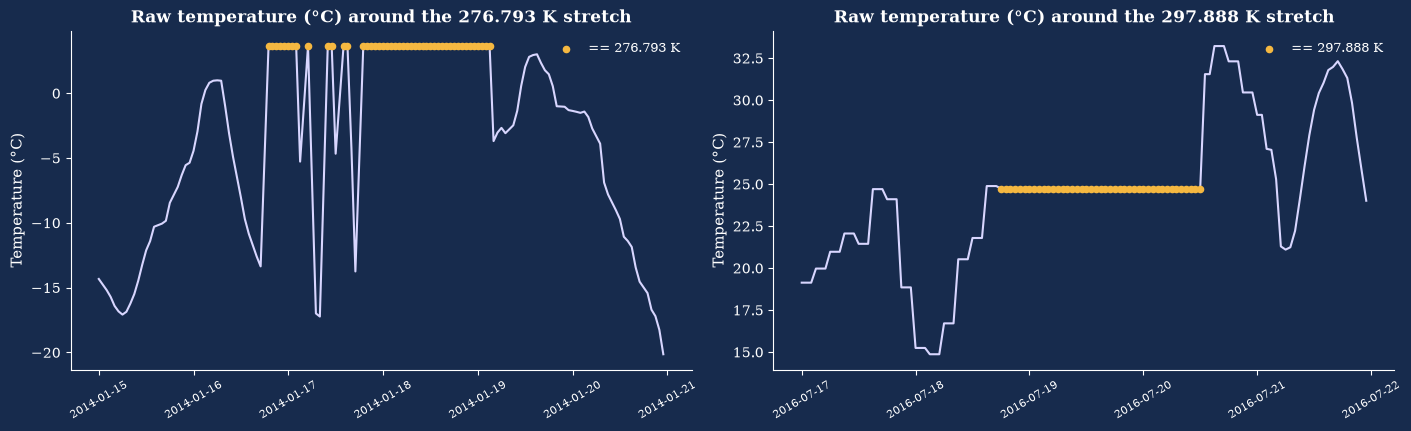

In [29]:
raw_med = raw.groupby('date_time').temp.median().sort_index()     # hourly median of the raw reports (K)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), facecolor=THEME_BG, constrained_layout=True)
for ax, (a, b), v in zip(axes, [('2014-01-15', '2014-01-20'), ('2016-07-17', '2016-07-21')], TEMP_SENTINELS):
    w = raw_med[a:b] - KELVIN_OFFSET
    ax.plot(w.index, w.values, color=THEME_LAVENDER, lw=1.5)
    hit = w[raw_med[a:b] == v]
    ax.scatter(hit.index, hit.values, color=THEME_ACCENT, s=20, zorder=3, label=f'== {v} K')
    style_axes(ax, title=f'Raw temperature (°C) around the {v} K stretch', ylabel='Temperature (°C)', title_size=12)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    style_legend(ax)
plt.show()

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">276.793 K</code> (= <b>+3.6 °C</b>) appears across 78 rows (between October 2013 and January 2014; 70 of these rows are in January 2014 alone). The left plot shows that in the middle of a severe cold wave, where adjacent true temperatures range from −10 °C down to −26 °C, the reading abruptly jumps to +3.6 °C and sometimes stays flat for 33 consecutive hours.</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">297.888 K</code> (= +24.7 °C) repeats across 43 <b>consecutive</b> hours (2016-07-18 to 2016-07-20) with no diurnal cycle whatsoever, which is physically impossible in midsummer.</li></ul><p style="margin:0 0 8px 0;">These are "stuck" or placeholder values produced by the sensor or upstream data, <b>not real-world weather</b>. Unlike 0 K, they cannot be caught by a simple physical range check and are only exposed by examining repetition patterns. Left uncorrected, temperatures in these windows stay off by up to ~30 °C. Moreover, when several hourly readings are aggregated with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">median</code>, mixing stuck values with true values produces artificial intermediate figures.</p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.5 — Remaining Temperature Jumps (After Discarding Stuck Values)</h4></div>

In [30]:
t_chk = raw[(raw.temp > 0) & (~raw.temp.isin(TEMP_SENTINELS))].groupby('date_time').temp.median().sort_index()
adj = t_chk.index.to_series().diff() == pd.Timedelta(hours=1)
jump = t_chk.diff().abs()[adj]
print('adjacent-hour temp jumps > 10 °C (after masking sentinels):', int((jump > 10).sum()))
jump[jump > 10].rename('abs jump (°C)').to_frame()

adjacent-hour temp jumps > 10 °C (after masking sentinels): 1


,abs jump (°C)
date_time,
2013-02-03 18:00:00,14.14


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Removing the stuck values drops the number of severe hour-over-hour temperature spikes (&gt; 10 °C) from 8 down to 1, confirming that the other seven were purely artificial. The sole remaining incident is an isolated point on 2013-02-03 at 18:00, which reverts to baseline within two hours. While suspect, it is <b>unprovable</b> (a rapid weather front cannot be ruled out), so we leave it untouched. The governing rule: only modify what the evidence definitively supports.</p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.6 — Categorical Text: Casing Inconsistencies and Pair Alignment (main, description)</h4></div>

In [31]:
print('weather_description unique (raw):', raw.weather_description.nunique())
print('after lower/strip              :', raw.weather_description.str.lower().str.strip().nunique())
print(raw.weather_description[raw.weather_description.str.contains('clear|squall', case=False)].value_counts().to_dict())

pairs = raw.assign(d=raw.weather_description.str.lower().str.strip()).groupby('d').weather_main.nunique()
print('descriptions linked to >1 weather_main:', int((pairs > 1).sum()))

weather_description unique (raw): 38
,after lower/strip              : 37
,{'sky is clear': 11665, 'Sky is Clear': 1726, 'SQUALLS': 4}
,descriptions linked to >1 weather_main: 0


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Sky is Clear</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">sky is clear</code> represent the same category and are merged via lowercasing. <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">SQUALLS</code> exists only in uppercase (with no lowercase counterpart); it does not merge with another entry, but is lowercased for consistency.</li><li style="margin-bottom:4px;">Every <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_description</code> maps to exactly one <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_main</code>; in other words, <b>the pair (main, description) is a single semantic unit.</b> This becomes essential for the aggregation step:</li></ul></div>

In [32]:
tmp2 = raw.drop_duplicates().assign(weather_description=lambda x: x.weather_description.str.lower().str.strip())

def det_mode(s):
    vc = s.value_counts()
    return sorted(vc[vc == vc.max()].index)[0]

naive = tmp2.groupby('date_time').agg(m=('weather_main', det_mode), d=('weather_description', det_mode))
valid_pairs = set(map(tuple, tmp2[['weather_main', 'weather_description']].drop_duplicates().values))
incoherent = [(m, d) for m, d in zip(naive.m, naive.d) if (m, d) not in valid_pairs]
print('timestamps that would get an IMPOSSIBLE (main, description) pair:', len(incoherent))
print(pd.Series(incoherent).value_counts().head(5).to_string())

timestamps that would get an IMPOSSIBLE (main, description) pair: 1542
,(Mist, light snow)                 468
,(Mist, light rain)                 400
,(Mist, heavy snow)                 217
,(Mist, heavy intensity rain)       195
,(Drizzle, heavy intensity rain)     57


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">If the <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">mode</code> of each column is computed independently, it creates combinations such as <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Mist</code> + <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">light snow</code> across more than 1,500 hours: combinations that never existed in the original dataset. <b>Solution:</b> the <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">mode</code> must be computed on the *pair* (main, description) as a single entity.</p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.7 — Temporal Coverage, Gaps, and Time Zone</h4></div>

expected hourly slots: 52,551 | present: 40,575 | absent: 11,976 (22.8%)
,
,gaps longer than 48h:
,  2014-08-08 01:00:00 -> 2015-06-11 20:00:00   (307 days 19 h)
,  2013-10-27 01:00:00 -> 2013-11-06 04:00:00   (10 days 3 h)
,  2015-06-14 20:00:00 -> 2015-06-19 18:00:00   (4 days 22 h)
,  2014-04-29 08:00:00 -> 2014-05-04 05:00:00   (4 days 21 h)
,  2015-10-23 11:00:00 -> 2015-10-27 08:00:00   (3 days 21 h)
,  2014-07-27 16:00:00 -> 2014-07-30 09:00:00   (2 days 17 h)


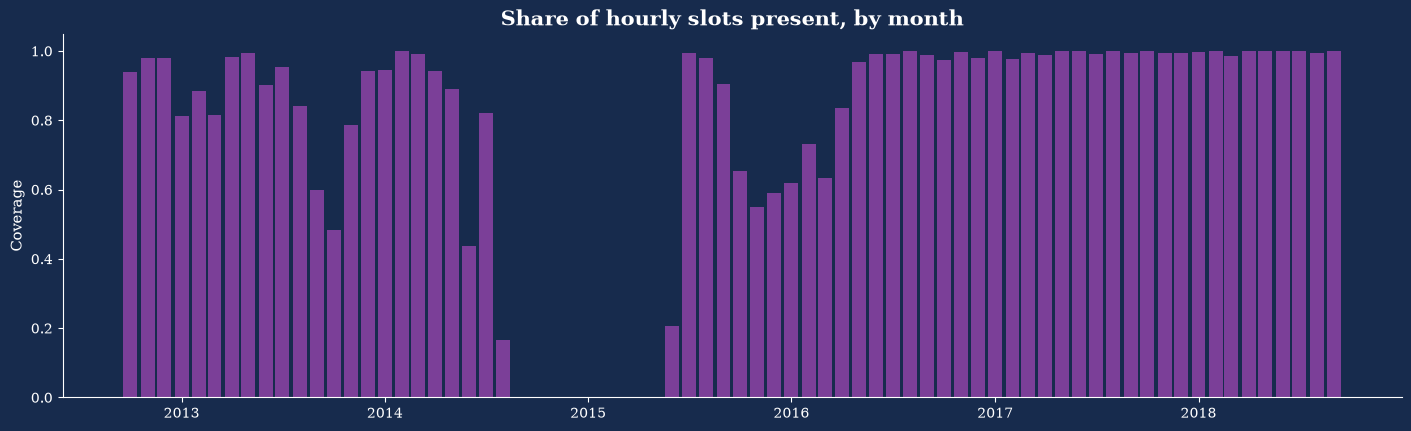

In [33]:
ts = pd.DatetimeIndex(sorted(raw.date_time.unique()))
full = pd.date_range(ts.min(), ts.max(), freq='h')
print(f'expected hourly slots: {len(full):,} | present: {len(ts):,} | absent: {len(full)-len(ts):,} ({100*(len(full)-len(ts))/len(full):.1f}%)')

gaps = pd.Series(ts[1:] - ts[:-1], index=ts[1:])
big = gaps[gaps > pd.Timedelta(hours=48)].sort_values(ascending=False)
print('\ngaps longer than 48h:')
for end, g in big.head(6).items():
    print(f'  {end - g} -> {end}   ({g.days} days {g.seconds//3600} h)')

cov = pd.Series(1, index=ts).resample('MS').sum() / (pd.Series(1, index=full).resample('MS').sum())
fig, ax = plt.subplots(figsize=(14, 4.2), facecolor=THEME_BG, constrained_layout=True)
ax.bar(cov.index, cov.values, width=25, color=THEME_PURPLE)
style_axes(ax, title='Share of hourly slots present, by month', ylabel='Coverage', title_size=15)
ax.set_ylim(0, 1.05)
plt.show()

In [34]:
t0 = raw.drop_duplicates('date_time').set_index('date_time').traffic_volume
wd0 = t0[t0.index.dayofweek < 5]
for m, name in [(1, 'January'), (7, 'July')]:
    s = wd0[wd0.index.month == m]
    print(name, 'top-3 weekday hours:', s.groupby(s.index.hour).mean().nlargest(3).index.tolist())
print('hours present on 2014-03-09 (US spring-forward day):', [int(h) for h in sorted(raw[raw.date_time.dt.strftime('%Y-%m-%d') == '2014-03-09'].date_time.dt.hour.unique())[:5]], '...')

January top-3 weekday hours: [16, 17, 7]
,July top-3 weekday hours: [16, 7, 17]
,hours present on 2014-03-09 (US spring-forward day): [0, 1, 3, 4, 5] ...


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;">About <b>23 % of all hourly slots are missing</b> from the dataset (11,976 of 52,551), with the largest gap spanning ≈ 10 months (2014-08 to 2015-06). The "previous row" can therefore be months in the past: a naive <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">shift()</code> would build invalid lag features, and missing target values <b>must never be interpolated/imputed</b>.</li><li style="margin-bottom:4px;">Morning and evening peak hours are identical across winter and summer, and 02:00 is omitted on the spring-forward day; this confirms that <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">date_time</code> is effectively <b>local wall-clock time (observing DST)</b>, despite the dataset documentation specifying CST. Consequently <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code> and peak-hour features need no DST adjustment.</li></ul></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.8 — Target Variable: Near-Zero Clusters</h4></div>

In [35]:
tv = raw.drop_duplicates('date_time').set_index('date_time').sort_index().traffic_volume
print('1st percentile of traffic by hour (min over hours):', int(tv.groupby(tv.index.hour).quantile(0.01).min()))

low = tv[tv < LOW_VOLUME_THRESHOLD]
cl = (low.index.to_series().diff() > pd.Timedelta(hours=3)).cumsum()
low_clusters = low.groupby(cl).agg(start=lambda s: s.index.min(), end=lambda s: s.index.max(), n='size', median_tv='median')
print(f'timestamps with traffic_volume < {LOW_VOLUME_THRESHOLD}: {len(low)} in {len(low_clusters)} contiguous clusters')
low_clusters

1st percentile of traffic by hour (min over hours): 209
,timestamps with traffic_volume < 100: 46 in 9 contiguous clusters


,start,end,n,median_tv
date_time,,,,
0,2015-07-24 22:00:00,2015-07-24 22:00:00,1,65.0
1,2015-07-25 08:00:00,2015-07-25 09:00:00,2,1.0
2,2016-07-09 20:00:00,2016-07-09 23:00:00,4,10.5
3,2016-07-22 22:00:00,2016-07-23 04:00:00,7,7.0
4,2016-07-23 09:00:00,2016-07-24 04:00:00,20,4.0
5,2016-07-24 09:00:00,2016-07-24 11:00:00,2,19.5
6,2016-07-24 16:00:00,2016-07-24 16:00:00,1,44.0
7,2016-08-31 23:00:00,2016-09-01 02:00:00,4,7.0
8,2016-09-07 23:00:00,2016-09-08 03:00:00,5,3.0


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Even in the dead of night, the lowest 1 % of traffic volume still registers several hundred vehicles; counts between 1 and 15 are therefore <b>never typical for any hour</b>. These values are not scattered randomly; they appear in several <b>continuous clusters</b> (sometimes persisting for ~20 consecutive hours) during the summers of 2015 and 2016. This suggests either a hardware/sensor failure or an actual highway closure. Because the data itself does not provide enough information to determine the root cause, we <b>leave the target untouched</b> and simply set a <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_low_volume</code> flag so the modeling team can decide how to handle it (e.g., segmenting it in error analysis).</p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.2.9 — Audit Summary</h4></div>

In [36]:
pd.DataFrame([
    ('exact duplicate rows', n_exact, 'already dropped in the EDA section (verified in 4.3.1)'),
    ('timestamps with >1 report', int((sizes > 1).sum()), 'collapse to 1 row/hour (median numerics, joint-mode weather pair)'),
    ('temp <= 0 K', int((raw.temp <= 0).sum()), 'NaN -> time interpolation + flag'),
    ('temp stuck at 276.793 / 297.888 K', int(raw.temp.isin(TEMP_SENTINELS).sum()), 'NaN (before collapse) -> time interpolation + flag'),
    ('rain_1h > 100', int((raw.rain_1h > RAIN_MAX_PLAUSIBLE).sum()), 'NaN -> same-label median + flag'),
    ('"Sky is Clear" casing', int((raw.weather_description == 'Sky is Clear').sum()), 'lower/strip BEFORE collapsing'),
    ('holiday NaN (structural)', int(raw.holiday.isna().sum()), 'column excluded from the features (team decision); no imputation'),
    ('weather label columns', 2, 'helper only inside 4.3 (merge hours, impute rain), then dropped from the features'),
    ('absent hourly slots', len(full) - len(ts), 'document; never fill target'),
    (f'traffic_volume < {LOW_VOLUME_THRESHOLD} (unique ts)', len(low), 'keep, flag only'),
], columns=['finding', 'count', 'action'])

,finding,count,action
0,exact duplicate rows,17,already dropped in the EDA section (verified i...
1,timestamps with >1 report,5430,"collapse to 1 row/hour (median numerics, joint..."
2,temp <= 0 K,10,NaN -> time interpolation + flag
3,temp stuck at 276.793 / 297.888 K,121,NaN (before collapse) -> time interpolation + ...
4,rain_1h > 100,1,NaN -> same-label median + flag
5,"""Sky is Clear"" casing",1726,lower/strip BEFORE collapsing
6,holiday NaN (structural),48143,column excluded from the features (team decisi...
7,weather label columns,2,"helper only inside 4.3 (merge hours, impute ra..."
8,absent hourly slots,11976,document; never fill target
9,traffic_volume < 100 (unique ts),46,"keep, flag only"


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">4.3 — Data Cleaning (Step-by-Step)</h3></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The order is deliberate: <b>EDA frame → text normalization → impossible values to <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">NaN</code> (before aggregation) → hourly aggregation → imputation → Kelvin to °C → weather labels dropped → target flagging.</b></p></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.1 — Starting Point: the EDA Frame</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Traffic</code> from the EDA section is the starting point. It already has the exact duplicates removed and the <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">month</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code> columns, but <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">date_time</code> was dropped there. So:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">date_time</code> is rebuilt from those four columns and verified against the raw timestamps (no second parse or extraction).</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">holiday</code> is dropped: holiday/event information is excluded from the features (team decision).</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day</code> (day of the month) is dropped: it carries no meaningful traffic signal.</li><li style="margin-bottom:4px;">Nothing is deduplicated again: assertions confirm the row count equals <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">raw</code> minus the exact duplicates. <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Traffic</code> itself is copied and never modified.</li></ul></div>

In [37]:
df = Traffic.copy()
df['date_time'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.drop(columns=['holiday', 'day']).sort_values('date_time').reset_index(drop=True)

# the EDA section already removed the exact duplicates, so there is nothing left to drop here
assert len(df) == len(raw) - n_exact
assert set(df.date_time) == set(raw.date_time)
print('rows:', len(raw), '->', len(df), f'(the EDA section already dropped {n_exact} exact duplicates)')

rows: 48204 -> 48187 (the EDA section already dropped 17 exact duplicates)


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.2 — Text Normalization (Before Aggregation, so <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Sky is Clear</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">sky is clear</code> Group Together)</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The weather label columns are <b>helper columns only</b> in this section: they are needed to merge duplicate hourly reports and to impute the single rain outlier (4.3.7), and they are dropped from the features in 4.3.8.</p></div>

In [38]:
for c in ['weather_main', 'weather_description']:
    df[c] = df[c].str.strip()
df['weather_description'] = df['weather_description'].str.lower()
assert 'SQUALLS' not in set(df.weather_description)
print('unique weather_description:', df.weather_description.nunique())

unique weather_description: 37


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.3 — Impossible/Stuck Values → NaN (Before Aggregation) + Flagging</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">If aggregated beforehand, the <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">median</code> across several reports would blend faulty values with valid readings, making them undetectable later; they are therefore converted to <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">NaN</code> first. Invalid temperature = "≤ 0 K" or "one of the two stuck values". Temperatures are still in Kelvin at this point because the stuck values are matched on the raw Kelvin numbers; the conversion to °C happens in 4.3.6.</p></div>

In [39]:
bad_temp = (df.temp <= 0) | df.temp.isin(TEMP_SENTINELS)
df.loc[bad_temp, 'temp'] = np.nan
df['qa_rain_invalid'] = (df.rain_1h > RAIN_MAX_PLAUSIBLE).astype('int8')
df.loc[df.qa_rain_invalid == 1, 'rain_1h'] = np.nan
print('temp reports -> NaN:', int(bad_temp.sum()), '| rain -> NaN:', int(df.qa_rain_invalid.sum()))

assert (df.groupby('date_time').traffic_volume.nunique() == 1).all()
print('target constant within every timestamp group: OK')

temp reports -> NaN: 131 | rain -> NaN: 1
,target constant within every timestamp group: OK


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.4 — Aggregating into "One Row Per Hour"</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;">Numeric measurements (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">temp</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">rain_1h</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">snow_1h</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">clouds_all</code>): <b>median</b> (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">NaN</code> values are ignored).</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">traffic_volume</code>: <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">first</code> (its constancy was verified above).</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">month</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code>: <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">first</code> (constant inside an hour; the EDA section's columns are reused, not re-extracted).</li><li style="margin-bottom:4px;">Weather labels (helper only): <b>mode on the pair (main, description)</b>; ties are broken alphabetically to guarantee deterministic, reproducible results.</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">clouds_all</code> may end up with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">.5</code> after the median; it is rounded to keep integer values.</li></ul></div>

In [40]:
num = df.groupby('date_time').agg(
    temp=('temp', 'median'), rain_1h=('rain_1h', 'median'), snow_1h=('snow_1h', 'median'),
    clouds_all=('clouds_all', 'median'), traffic_volume=('traffic_volume', 'first'),
    year=('year', 'first'), month=('month', 'first'), hour=('hour', 'first'),
    qa_rain_invalid=('qa_rain_invalid', 'max'),
    qa_n_reports=('traffic_volume', 'size'))

pc = (df.groupby(['date_time', 'weather_main', 'weather_description']).size().rename('n').reset_index()
        .sort_values(['date_time', 'n', 'weather_main', 'weather_description'], ascending=[True, False, True, True])
        .drop_duplicates('date_time').set_index('date_time')[['weather_main', 'weather_description']])

df = num.join(pc).sort_index()
df['clouds_all'] = np.rint(df['clouds_all']).astype('int16')

assert df.index.is_unique
# valid_pairs comes from the audit in 4.2.6
assert all((m, d) in valid_pairs for m, d in zip(df.weather_main, df.weather_description))
print('shape:', df.shape, '| every (main, description) pair exists in the raw data: OK')
print('remaining NaN:'); print(df.isna().sum()[lambda s: s > 0].to_string())

shape: (40575, 12) | every (main, description) pair exists in the raw data: OK
,remaining NaN:
,temp       127
,rain_1h      1


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.5 — Invalid Temperatures (0 K and Stuck Values): Time-Based Interpolation</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Temperature is a continuous time-series signal; interpolating between the two valid hours directly before and after the anomaly window is far more accurate than a global mean/median imputation. Safety constraint: interpolation is applied only if the gap between the two valid neighbours is <b>at most 48 hours</b>. Longer windows (gaps between valid neighbours of up to ~44 hours in this data) carry lower confidence and cannot capture the diurnal cycle, which is why <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_temp_imputed</code> tracks them so they can be isolated during error analysis. (Alternative: keep <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">NaN</code> for <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">temp</code> across these hours and use a model that handles missing values natively.)</p></div>

In [41]:
df['qa_temp_imputed'] = df.temp.isna().astype('int8')
bad_idx = df.index[df.temp.isna()]
valid_idx = df.index[df.temp.notna()]
rows = []
for ts_ in bad_idx:
    pos = valid_idx.searchsorted(ts_)
    prev_, next_ = valid_idx[pos - 1], valid_idx[pos]
    span = (next_ - prev_) / pd.Timedelta(hours=1)
    assert span <= INTERP_MAX_HOURS, f'gap too wide around {ts_}: {span} h'
    rows.append((ts_, span))

df['temp'] = df['temp'].interpolate(method='time', limit=INTERP_MAX_HOURS, limit_area='inside')
assert df.temp.isna().sum() == 0
assert not df.loc[df.qa_temp_imputed == 0, 'temp'].isin(TEMP_SENTINELS).any(), 'sentinel temp still present'
print('timestamps imputed:', len(bad_idx), '| max bridged span (h):', max(r[1] for r in rows))

timestamps imputed: 127 | max bridged span (h): 44.0


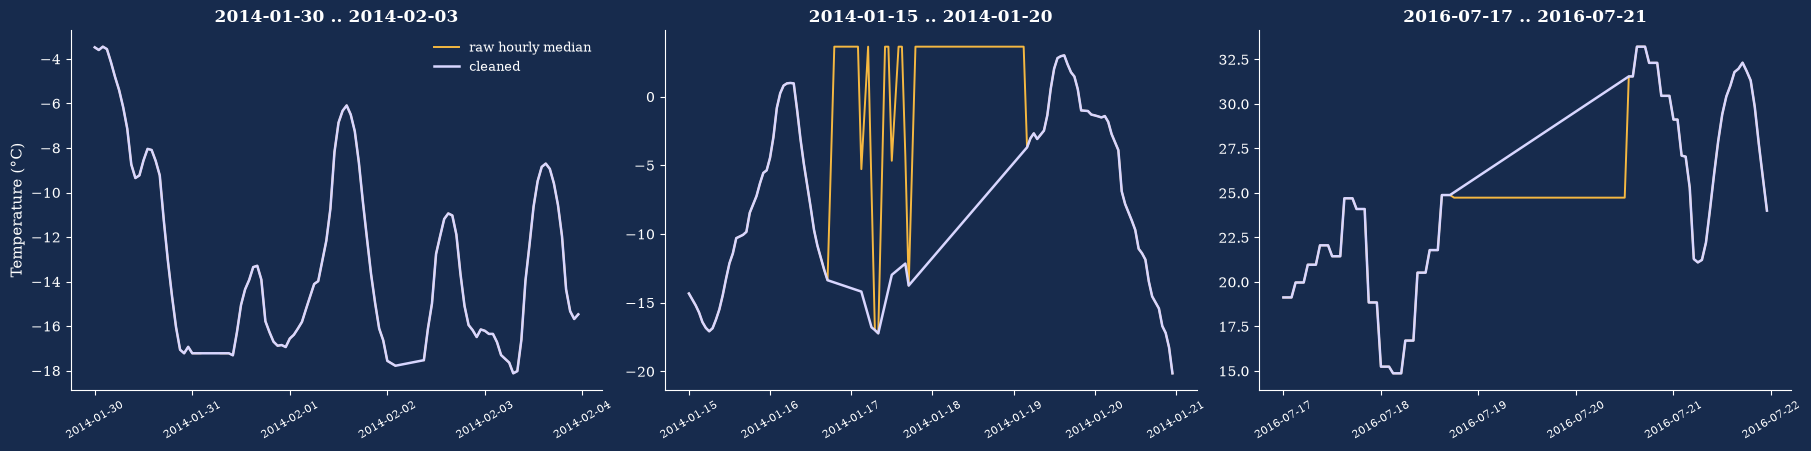

In [42]:
# before / after: raw hourly median (raw_med, from 4.2.4) vs the cleaned series
wins = [('2014-01-30', '2014-02-03'), ('2014-01-15', '2014-01-20'), ('2016-07-17', '2016-07-21')]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.4), facecolor=THEME_BG, constrained_layout=True)
for i, (ax, (a, b)) in enumerate(zip(axes, wins)):
    before = raw_med[a:b].where(raw_med[a:b] > 0) - KELVIN_OFFSET      # 0 K shown as a gap
    ax.plot(before.index, before.values, color=THEME_ACCENT, lw=1.4, label='raw hourly median')
    after = df.loc[a:b, 'temp'] - KELVIN_OFFSET
    ax.plot(after.index, after.values, color=THEME_LAVENDER, lw=1.8, label='cleaned')
    style_axes(ax, title=f'{a} .. {b}', ylabel='Temperature (°C)' if i == 0 else None, title_size=12)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
style_legend(axes[0])
plt.show()

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.6 — Kelvin → Celsius</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Cleaning and interpolation above work on the raw Kelvin values. From here on the project uses <b>°C</b>: <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">temp_c = temp − 273.15</code>, rounded to the sensor's 0.01 resolution, and the Kelvin column is dropped so that no Kelvin value reaches the feature set.</p></div>

In [43]:
df['temp_c'] = (df['temp'] - KELVIN_OFFSET).round(2)
df = df.drop(columns=['temp'])
print('temp_c range: %.1f .. %.1f °C' % (df.temp_c.min(), df.temp_c.max()))

temp_c range: -29.8 .. 36.9 °C


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.7 — Rain Outlier 9,831.3: Imputation via Label-Matched Median</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The value is imputed with the <b>median</b> of the records sharing the exact same <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_description</code> (this row itself holds "very heavy rain"). Rationale: it stays consistent with the row's label while remaining well within the empirical range of the dataset. <b>Capping at 100</b> would create an artificial value larger than any other reading in the data, which <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">log1p</code> then amplifies. The overall impact on the model is negligible (a single row out of more than 40,000), and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_rain_invalid</code> keeps track of it; should the team prefer an alternative (e.g., setting it to 0 like the adjacent hours), only this individual cell needs modification.</p></div>

In [44]:
bad = df.rain_1h.isna()
ref = df[~bad].groupby('weather_description').rain_1h.median()
print('rows to impute:', int(bad.sum()), '| label:', df.loc[bad, 'weather_description'].tolist())
df.loc[bad, 'rain_1h'] = df.loc[bad, 'weather_description'].map(ref)
assert df.rain_1h.isna().sum() == 0
print('imputed rain_1h (mm/h):', df.loc[df.qa_rain_invalid == 1, 'rain_1h'].round(2).tolist(),
      '| max rain now:', df.rain_1h.max())

rows to impute: 1 | label: ['very heavy rain']
,imputed rain_1h (mm/h): [23.75] | max rain now: 55.63


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.8 — Weather Label Columns Removed from the Features</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_main</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_description</code> have now served their purpose (merging duplicate hourly reports and imputing the rain outlier), so they are dropped: weather labels are <b>not</b> features. The numeric weather measurements (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">temp_c</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">rain_1h</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">snow_1h</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">clouds_all</code>) are kept.</p></div>

In [45]:
df = df.drop(columns=['weather_main', 'weather_description'])
print('columns now:', list(df.columns))

columns now: ['rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'year', 'month', 'hour', 'qa_rain_invalid', 'qa_n_reports', 'qa_temp_imputed', 'temp_c']


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.3.9 — Flagging Suspect Target Values (Without Modifying the Target)</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The target <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">traffic_volume</code> is never modified. Hours below 100 vehicles/h are only flagged with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_low_volume</code> (see 4.2.8).</p></div>

In [46]:
df['qa_low_volume'] = (df.traffic_volume < LOW_VOLUME_THRESHOLD).astype('int8')
print('flagged:', int(df.qa_low_volume.sum()), f'({100*df.qa_low_volume.mean():.2f}% of rows)')

flagged: 46 (0.11% of rows)


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">4.4 — Feature Engineering</h3></div>
<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.4.1 — Calendar and Cyclical Features</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Retained: <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code> (long-term trend), <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">month</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day_of_week</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_weekend</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">season</code>. <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">month</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code> come straight from the EDA section; only <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day_of_week</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_weekend</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">season</code> and the sin/cos encodings are new here. <b>Deliberately omitted:</b> <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day_name</code> (redundant with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day_of_week</code>), <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">week_of_year</code>/<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day_of_year</code> (high collinearity with month) and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day</code> (day of the month; carries no meaningful traffic signal).</p><p style="margin:0 0 8px 0;">Hour, day of the week and month are cyclical: 23 and 0 differ by 23 units numerically, yet they are adjacent in time. A <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">sin/cos</code> transformation resolves this for linear models and neural networks (tree-based models do not need it).</p></div>

In [47]:
idx = df.index
df['day_of_week'] = idx.dayofweek          # 0 = Monday
df['is_weekend'] = (df.day_of_week >= 5).astype('int8')
df['season'] = pd.Categorical(df.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                            6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'}),
                              categories=['Winter', 'Spring', 'Summer', 'Fall'])
for name, val, period in [('hour', df.hour, 24), ('dow', df.day_of_week, 7), ('month', df.month - 1, 12)]:
    df[f'{name}_sin'] = np.sin(2 * np.pi * val / period)
    df[f'{name}_cos'] = np.cos(2 * np.pi * val / period)
df[['year', 'month', 'hour', 'day_of_week', 'season', 'hour_sin', 'hour_cos']].head(3)

,year,month,hour,day_of_week,season,hour_sin,hour_cos
date_time,,,,,,,
2012-10-02 09:00:00,2012,10,9,1,Fall,0.707107,-0.707107
2012-10-02 10:00:00,2012,10,10,1,Fall,0.500000,-0.866025
2012-10-02 11:00:00,2012,10,11,1,Fall,0.258819,-0.965926


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.4.2 — Rush Hour</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Rush hours are established from domain knowledge (business commuting patterns); the data only <b>validates</b> them. Key takeaway: weekends show an entirely different pattern (no morning peak), so <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_rush_hour</code> is active on <b>workdays</b> only.</p></div>

hours >= 85% of weekday peak: [6, 7, 8, 15, 16, 17] | chosen a priori: [6, 7, 8, 15, 16, 17]


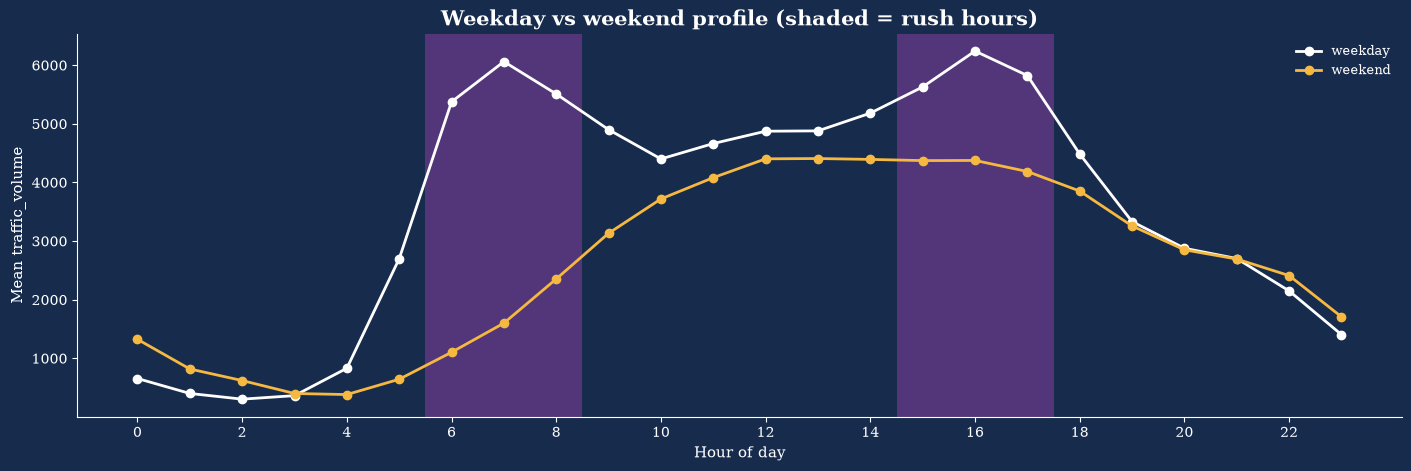

mean traffic: rush 5773 | non-rush 2756


In [48]:
prof = df.groupby(['hour', 'is_weekend']).traffic_volume.mean().unstack('is_weekend')
prof.columns = ['weekday', 'weekend']

data_rush = prof.index[prof.weekday >= 0.85 * prof.weekday.max()].tolist()
print('hours >= 85% of weekday peak:', data_rush, '| chosen a priori:', RUSH_HOURS)
assert data_rush == RUSH_HOURS

fig, ax = plt.subplots(figsize=(14, 4.6), facecolor=THEME_BG, constrained_layout=True)
for h in RUSH_HOURS:
    ax.axvspan(h - .5, h + .5, color=THEME_PURPLE, alpha=.6, linewidth=0)
ax.plot(prof.index, prof.weekday, marker='o', color='white', lw=2, label='weekday')
ax.plot(prof.index, prof.weekend, marker='o', color=THEME_ACCENT, lw=2, label='weekend')
ax.set_xticks(range(0, 24, 2))
style_axes(ax, title='Weekday vs weekend profile (shaded = rush hours)', xlabel='Hour of day',
           ylabel='Mean traffic_volume', title_size=15)
style_legend(ax)
plt.show()

df['is_rush_hour'] = ((df.day_of_week < 5) & df.hour.isin(RUSH_HOURS)).astype('int8')
print('mean traffic: rush %.0f | non-rush %.0f' % (df.loc[df.is_rush_hour == 1, 'traffic_volume'].mean(),
                                                  df.loc[df.is_rush_hour == 0, 'traffic_volume'].mean()))

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">4.4.3 — Weather Features (Numeric)</h4></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">temp_c</code>: temperature in °C (cleaned in 4.3.5 and converted from Kelvin in 4.3.6).</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_freezing</code>: binary flag for temperatures below 0 °C.</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_raining</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_snowing</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">precipitation_flag</code>: about 95 % of rows record zero precipitation; a binary presence/absence flag provides a discrete signal that gets drowned out in the raw continuous values.</li><li style="margin-bottom:4px;"><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">rain_1h_log1p</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">snow_1h_log1p</code>: highly right-skewed distributions, log-transformed with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">log1p</code> for scale-sensitive models.</li></ul><p style="margin:0 0 8px 0;">The weather <b>labels</b> (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_main</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_description</code>) are intentionally not features (see 4.3.8).</p></div>

In [49]:
df['is_freezing'] = (df.temp_c < 0).astype('int8')
df['is_raining'] = (df.rain_1h > 0).astype('int8')
df['is_snowing'] = (df.snow_1h > 0).astype('int8')
df['precipitation_flag'] = ((df.rain_1h > 0) | (df.snow_1h > 0)).astype('int8')
df['rain_1h_log1p'] = np.log1p(df.rain_1h)
df['snow_1h_log1p'] = np.log1p(df.snow_1h)
print('share with rain: %.3f | snow: %.4f' % (df.is_raining.mean(), df.is_snowing.mean()))

share with rain: 0.051 | snow: 0.0008


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">4.5 — Final Validation (Explicit Asserts) and Export</h3></div>
<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The next cell puts the columns in their final order (target, features, then <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_*</code> columns) and runs explicit <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">assert</code> checks, so the notebook fails loudly if any step is broken or reordered. The clean dataset is then saved to <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">../data/data_cleaning.csv</code>.</p></div>

In [50]:
# ---- final column layout ----
TARGET = 'traffic_volume'
QA_COLS = [c for c in df.columns if c.startswith('qa_')]      # all audit/trace columns carry the qa_ prefix
FEATURES = [c for c in df.columns if c != TARGET and c not in QA_COLS]
df = df[[TARGET] + FEATURES + QA_COLS].sort_index()

# ---- assertions: the notebook fails loudly if anything is violated ----
raw_tv = raw.drop_duplicates('date_time').set_index('date_time').traffic_volume
assert df.index.is_unique and df.index.is_monotonic_increasing
assert len(df) == raw.date_time.nunique()
assert df.isna().sum().sum() == 0, 'unexpected missing values'
assert df[TARGET].equals(raw_tv.reindex(df.index)), 'target was modified!'
assert 'temp' not in df.columns and df.temp_c.between(-50, 50).all(), 'temperature must be in degrees C'
assert df.rain_1h.between(0, 60).all() and df.snow_1h.between(0, 1).all() and df.clouds_all.between(0, 100).all()
assert df.loc[df.is_weekend == 1, 'is_rush_hour'].sum() == 0
assert not df.columns.str.contains('holiday|state_fair|weather').any(), 'weather/holiday columns must not be in the output'
assert all(not c.startswith('qa_') for c in FEATURES) and TARGET not in FEATURES
print('ALL ASSERTIONS PASSED')
print('rows x cols:', df.shape, '| features:', len(FEATURES), '| qa columns:', QA_COLS)

ALL ASSERTIONS PASSED
,rows x cols: (40575, 28) | features: 23 | qa columns: ['qa_rain_invalid', 'qa_n_reports', 'qa_temp_imputed', 'qa_low_volume']


In [51]:
dictionary = pd.DataFrame({'dtype': df[FEATURES + QA_COLS].dtypes.astype(str),
                           'n_unique': df[FEATURES + QA_COLS].nunique(),
                           'role': ['feature'] * len(FEATURES) + ['QA / do NOT train on'] * len(QA_COLS)})
dictionary

,dtype,n_unique,role
rain_1h,float64,375,feature
snow_1h,float64,12,feature
clouds_all,int16,64,feature
year,int32,7,feature
month,int32,12,feature
hour,int32,24,feature
temp_c,float64,5460,feature
day_of_week,int32,7,feature
is_weekend,int8,2,feature
season,category,4,feature


In [52]:
OUTPUT_PATH = '../data/data_cleaning.csv'
out = df.reset_index()
out.to_csv(OUTPUT_PATH, index=False)
print('saved:', OUTPUT_PATH, '| shape:', out.shape)

saved: ../data/data_cleaning.csv | shape: (40575, 29)


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">4.6 — Summary Report</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;">
<p style="margin:0 0 8px 0;">Starting from the EDA frame, we <b>audited the raw CSV before changing anything</b>, cleaned it in a deliberate order, engineered features, and validated everything with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px;">assert</code> checks.</p>
<p style="margin:0;"><b>Result:</b> 48,204 raw rows → <b>40,575 rows (one per hour)</b>, 0 missing values, 23 features + the target + 4 <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px;">qa_*</code> columns. The target <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px;">traffic_volume</code> was never modified (asserted against the raw data).</p>
</div>

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">Problems found and how we solved them</h4></div>

<table style="width:100%; border-collapse:collapse; font-family:'Segoe UI', sans-serif; font-size:0.95em; color:#1f2937; direction:ltr; text-align:left;">
<thead><tr style="background:#1e3a5f; color:#ffffff;">
<th style="padding:8px 10px; border:1px solid #b8c2cc;">Problem (evidence)</th>
<th style="padding:8px 10px; border:1px solid #b8c2cc;">Solution</th>
</tr></thead>
<tbody>
<tr><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b>Duplicates</b>: 17 exact rows, plus 5,430 hours with 2–6 reports (the target is identical inside each hour; only the weather report differs)</td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Exact duplicates dropped in the EDA. Merged to <b>one row per hour</b>: median for numeric columns, mode on the <b>(main, description) pair</b> for labels, so no impossible pairs such as <i>Mist + light snow</i>.</td></tr>
<tr style="background:#f4f7fb;"><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b>Invalid temperatures</b>: 0 K (10 rows) and stuck values 276.793 K / 297.888 K (121 rows, up to 43 consecutive hours, off by up to ~30 °C)</td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Set to <code>NaN</code> <b>before</b> merging, time-interpolated (max 48 h between valid neighbours), converted to °C, flagged with <code>qa_temp_imputed</code> (127 hours).</td></tr>
<tr><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b>Rain = 9,831.3 mm/h</b> (next highest real value: 55.6; neighbouring hours: 0)</td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Imputed with the median of rows sharing the same label (≈ 23.75 mm) instead of an arbitrary cap; flagged with <code>qa_rain_invalid</code>.</td></tr>
<tr style="background:#f4f7fb;"><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b>Label casing</b>: <i>Sky is Clear</i> vs <i>sky is clear</i></td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Lower-cased and stripped before merging.</td></tr>
<tr><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b><code>holiday</code> is 99.87 % empty</b> (structural absence)</td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Not imputed. Holiday/event information and the weather labels are excluded from the features (team decision); the labels are used only as helpers, then dropped.</td></tr>
<tr style="background:#f4f7fb;"><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b>Missing hours</b>: 22.8 % of hourly slots, with a 307-day gap (Aug 2014 → Jun 2015)</td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Documented only. The target is never filled and no lag features are built.</td></tr>
<tr><td style="padding:8px 10px; border:1px solid #b8c2cc;"><b>Suspicious target values</b>: 46 hours below 100 vehicles/h in 9 clusters (sensor outage or road closure, which cannot be told apart)</td>
<td style="padding:8px 10px; border:1px solid #b8c2cc;">Kept unchanged and flagged with <code>qa_low_volume</code>.</td></tr>
</tbody>
</table>

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">Features, limitations and next steps</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;">
<ul style="margin:4px 0 8px 22px; padding:0;">
<li><b>Features:</b> calendar (<code>year</code>, <code>month</code>, <code>day_of_week</code>, <code>hour</code>, <code>is_weekend</code>, <code>season</code>), sin/cos encodings of hour, day of week and month, weekday-only <code>is_rush_hour</code> (hours 6–8 and 15–17), and numeric weather (<code>temp_c</code>, freezing/rain/snow/precipitation flags, <code>log1p</code> of rain and snow, plus raw <code>rain_1h</code>, <code>snow_1h</code>, <code>clouds_all</code>).</li>
<li><b>Limitations:</b> 127 interpolated temperature hours lose their daily cycle; one suspicious but unprovable temperature jump (2013-02-03 18:00) was left as is; the 307-day gap splits the series in two.</li>
<li><b>For modeling:</b> use a time-based train/test split, never train on <code>qa_*</code> columns (<code>qa_low_volume</code> would leak the target), fit scalers and encoders on the training set only, and re-run the EDA statistics on the cleaned file.</li>
</ul>
<p style="margin:0;"><b>Output:</b> <code>../data/data_cleaning.csv</code> (40,575 × 29, including <code>date_time</code>).</p>
</div>

<a id="5"></a>
<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif;"><h2 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">Linear Regression</h2></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.1 — Setup and Carried-Over Assumptions</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">This notebook starts from the clean file written by section 4.5 of the cleaning notebook (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">../data/data_cleaning.csv</code>, one row per hour). <b>Every decision made there is kept</b>:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>Target</b> <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">traffic_volume</code> is never modified, filled or imputed.</li><li style="margin-bottom:4px;"><b>Features</b> = the 23 columns built in 4.4 (calendar, sin/cos encodings, rush hour, numeric weather). Columns with the prefix <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_</code> are audit columns and are <b>never used as features</b> (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_low_volume</code> would leak the target).</li><li style="margin-bottom:4px;"><b>No</b> holiday/event columns and <b>no</b> weather label columns in the baseline (team decision). Section 6 tests that decision explicitly.</li><li style="margin-bottom:4px;"><b>Temperature</b> is in &deg;C (cleaned and interpolated in 4.3.5/4.3.6).</li><li style="margin-bottom:4px;"><b>Time-based split</b>: the oldest 80&nbsp;% of the hours train the model, the newest 20&nbsp;% test it. No random shuffling, because neighbouring hours are strongly correlated and shuffling would leak.</li><li style="margin-bottom:4px;"><b>Scaler and encoder are fitted on the training set only</b> (inside a scikit-learn <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Pipeline</code>).</li><li style="margin-bottom:4px;"><b>No lag features</b>: 22.8&nbsp;% of the hourly slots are missing, so a &ldquo;previous row&rdquo; can be months away.</li></ul></div>

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">5.1.1 — Imports, Paths and Chart Theme</h4></div>

In [53]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

CLEAN_PATH = '../data/data_cleaning.csv'                      # written by section 4.5
RAW_PATH = '../data/Metro_Interstate_Traffic_Volume.csv'      # only needed in section 6 (weather labels)
TARGET = 'traffic_volume'
TEST_FRACTION = 0.20

# Chart theme: identical to the cleaning notebook (dark navy background, purple, white serif text)
THEME_BG = '#172B4D'
THEME_PURPLE = '#7B3F98'
THEME_LAVENDER = '#D8D6FF'
THEME_ACCENT = '#F5B841'


def style_axes(ax, title=None, xlabel=None, ylabel=None, title_size=13):
    # Apply the notebook's dark theme to one axes.
    ax.set_facecolor(THEME_BG)
    if title is not None:
        ax.set_title(title, fontsize=title_size, fontweight='bold', fontfamily='serif', color='white')
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=11, fontfamily='serif', color='white')
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=11, fontfamily='serif', color='white')
    ax.tick_params(axis='both', colors='white', labelfontfamily='serif')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')


def style_legend(ax, **kwargs):
    return ax.legend(frameon=False, labelcolor='white', prop={'family': 'serif', 'size': 9}, **kwargs)

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.2 — Load the Clean Data and Split by Time</h3></div>

In [54]:
df = (pd.read_csv(CLEAN_PATH, parse_dates=['date_time'])
        .sort_values('date_time').set_index('date_time'))

QA_COLS = [c for c in df.columns if c.startswith('qa_')]
FEATURES = [c for c in df.columns if c != TARGET and c not in QA_COLS]
CAT_COLS = ['season']
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

assert df.index.is_unique and df.index.is_monotonic_increasing
assert df.isna().sum().sum() == 0
assert len(FEATURES) == 23, 'the cleaning notebook defines 23 features'
assert not any(c.startswith('qa_') for c in FEATURES)
print('rows:', len(df), '| features:', len(FEATURES), '| qa columns (never features):', QA_COLS)

# ---- chronological split ----
split_idx = int(len(df) * (1 - TEST_FRACTION))
train, test = df.iloc[:split_idx], df.iloc[split_idx:]
print(f'train: {len(train):,} rows  {train.index.min()} -> {train.index.max()}')
print(f'test : {len(test):,} rows  {test.index.min()} -> {test.index.max()}')
print('years in train:', sorted(train.year.unique().tolist()), '| years in test:', sorted(test.year.unique().tolist()))

rows: 40575 | features: 23 | qa columns (never features): ['qa_rain_invalid', 'qa_n_reports', 'qa_temp_imputed', 'qa_low_volume']
,train: 32,460 rows  2012-10-02 09:00:00 -> 2017-10-26 17:00:00
,test : 8,115 rows  2017-10-26 18:00:00 -> 2018-09-30 23:00:00
,years in train: [2012, 2013, 2014, 2015, 2016, 2017] | years in test: [2017, 2018]


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;"><b>Note on <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code>:</b> with a time-based split, the test period can contain a <b>year value that never appears in training</b>. A linear model then extrapolates the year trend linearly. This is realistic for forecasting but can inflate test error; compare the models below with and without <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">year</code> if the test error looks odd.</p></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.3 — Helper Functions (Pipeline, Metrics, Diagnostics)</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Everything below is reusable: each model in this notebook is fitted by the single function <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">run_model()</code> and stored in the dictionary <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">RESULTS</code>. <b>Because of that, any optional section can be deleted without breaking the rest.</b></p></div>

In [55]:
RESULTS = {}


def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def score(y, yhat, n_params):
    r2 = r2_score(y, yhat)
    return {'R2': r2,
            'Adj_R2': adj_r2(r2, len(y), n_params),
            'MAE': mean_absolute_error(y, yhat),
            'RMSE': float(np.sqrt(mean_squared_error(y, yhat)))}


def build_pipeline(num_cols, cat_cols=()):
    # numeric columns -> StandardScaler, categorical -> one-hot (first level dropped as reference)
    steps = [('num', StandardScaler(), list(num_cols))]
    if len(cat_cols):
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), list(cat_cols)))
    prep = ColumnTransformer(steps, verbose_feature_names_out=False)
    prep.set_output(transform='pandas')
    return Pipeline([('prep', prep), ('lr', LinearRegression())])


def run_model(name, data, num_cols, cat_cols=(), train_filter=None, log_target=False, note=''):
    # Fit one linear regression on the chronological train part and score it on the test part.
    # train_filter: optional boolean Series (same index as data) that removes rows from TRAINING only.
    # log_target:   fit on log1p(traffic_volume), then back-transform; all metrics stay in vehicles/hour.
    cat_cols = list(cat_cols)
    cols = list(num_cols) + cat_cols
    tr, te = data.iloc[:split_idx], data.iloc[split_idx:]
    if train_filter is not None:
        tr = tr[train_filter.loc[tr.index].values]

    y_tr, y_te = tr[TARGET], te[TARGET]
    y_fit = np.log1p(y_tr) if log_target else y_tr
    pipe = build_pipeline(num_cols, cat_cols).fit(tr[cols], y_fit)

    def predict(d):
        raw_pred = pipe.predict(d[cols])
        return np.clip(np.expm1(raw_pred), 0, None) if log_target else raw_pred

    yhat_tr, yhat_te = predict(tr), predict(te)
    prep = pipe.named_steps['prep']
    n_params = len(prep.get_feature_names_out())
    X_tr = prep.transform(tr[cols])
    res = dict(name=name, note=note, n_train=len(tr), n_features=n_params, log_target=log_target,
               train=score(y_tr, yhat_tr, n_params), test=score(y_te, yhat_te, n_params),
               pipe=pipe, X_tr=X_tr, resid_fit=pd.Series(np.asarray(y_fit) - pipe.predict(tr[cols]), index=tr.index),
               idx_te=te.index, y_te=y_te, yhat_te=pd.Series(yhat_te, index=te.index))
    RESULTS[name] = res
    return res


def metrics_table(results):
    rows = []
    for r in results:
        rows.append({'model': r['name'], 'n_features': r['n_features'], 'n_train': r['n_train'],
                     'train R2': r['train']['R2'], 'test R2': r['test']['R2'], 'test adj R2': r['test']['Adj_R2'],
                     'train RMSE': r['train']['RMSE'], 'test RMSE': r['test']['RMSE'], 'test MAE': r['test']['MAE']})
    return pd.DataFrame(rows).set_index('model').round(3)


def cv_report(num_cols, cat_cols=(), n_splits=5):
    # Expanding-window cross-validation inside the TRAIN part only (the test part is never touched).
    cols = list(num_cols) + list(cat_cols)
    tr = df.iloc[:split_idx]
    rows = []
    for k, (a, b) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(tr), 1):
        pipe = build_pipeline(num_cols, cat_cols).fit(tr.iloc[a][cols], tr.iloc[a][TARGET])
        yh, y = pipe.predict(tr.iloc[b][cols]), tr.iloc[b][TARGET]
        rows.append({'fold': k, 'train rows': len(a), 'validation rows': len(b),
                     'R2': r2_score(y, yh), 'RMSE': np.sqrt(mean_squared_error(y, yh))})
    out = pd.DataFrame(rows).set_index('fold')
    out.loc['mean'] = out.mean()
    return out.round(3)


def diagnostics(res):
    # Six standard evaluation plots for one fitted model (test part).
    y, yh = res['y_te'], res['yhat_te']
    resid = y - yh
    fig, axes = plt.subplots(2, 3, figsize=(19, 10), facecolor=THEME_BG, constrained_layout=True)

    ax = axes[0, 0]
    ax.scatter(yh, y, s=6, alpha=0.35, color=THEME_PURPLE)
    lim = [min(y.min(), yh.min()), max(y.max(), yh.max())]
    ax.plot(lim, lim, color=THEME_ACCENT, lw=1.6, label='perfect prediction')
    style_axes(ax, 'Actual vs Predicted', 'Predicted traffic_volume', 'Actual traffic_volume')
    style_legend(ax)

    ax = axes[0, 1]
    ax.scatter(yh, resid, s=6, alpha=0.35, color=THEME_PURPLE)
    ax.axhline(0, color=THEME_ACCENT, lw=1.6)
    style_axes(ax, 'Residuals vs Predicted', 'Predicted traffic_volume', 'Residual (actual - predicted)')

    ax = axes[0, 2]
    sns.histplot(resid, bins=50, ax=ax, color=THEME_PURPLE)
    ax.axvline(0, color=THEME_ACCENT, lw=1.6)
    style_axes(ax, 'Residual Distribution', 'Residual', 'Frequency')

    ax = axes[1, 0]
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, s=6, alpha=0.5, color=THEME_PURPLE)
    ax.plot(osm, slope * np.asarray(osm) + intercept, color=THEME_ACCENT, lw=1.6)
    style_axes(ax, 'Normal Q-Q Plot of Residuals', 'Theoretical quantiles', 'Sample quantiles')

    ax = axes[1, 1]
    by_hour = resid.groupby(resid.index.hour).agg(['mean', 'std'])
    ax.plot(by_hour.index, by_hour['mean'], color='white', marker='o', lw=2, label='mean residual')
    ax.fill_between(by_hour.index, by_hour['mean'] - by_hour['std'], by_hour['mean'] + by_hour['std'],
                    color=THEME_PURPLE, alpha=0.55, label='+/- 1 std')
    ax.axhline(0, color=THEME_ACCENT, lw=1.4)
    ax.set_xticks(range(0, 24, 2))
    style_axes(ax, 'Residuals by Hour of Day', 'Hour', 'Residual')
    style_legend(ax)

    ax = axes[1, 2]
    last = y.index.max() - pd.Timedelta(days=7)
    w = y.index >= last
    ax.plot(y.index[w], y[w], color='white', lw=1.6, label='actual')
    ax.plot(yh.index[w], yh[w], color=THEME_ACCENT, lw=1.6, label='predicted')
    ax.tick_params(axis='x', rotation=30)
    style_axes(ax, 'Last 7 Days of the Test Period', None, 'traffic_volume')
    style_legend(ax)

    fig.suptitle(res['name'], fontsize=16, fontweight='bold', fontfamily='serif', color='white')
    plt.show()


def plot_coefficients(res, top=None):
    # Coefficients of the standardized model: effect on traffic_volume of +1 std (one-hot dummies: vs the reference level).
    names = res['pipe'].named_steps['prep'].get_feature_names_out()
    coef = pd.Series(res['pipe'].named_steps['lr'].coef_, index=names).sort_values(key=np.abs)
    if top:
        coef = coef.iloc[-top:]
    fig, ax = plt.subplots(figsize=(11, 0.38 * len(coef) + 2), facecolor=THEME_BG, constrained_layout=True)
    ax.barh(coef.index, coef.values, color=[THEME_PURPLE if v >= 0 else THEME_ACCENT for v in coef.values])
    ax.axvline(0, color='white', lw=0.8)
    style_axes(ax, 'Coefficients: ' + res['name'], 'Change in traffic_volume (vehicles/hour)')
    plt.show()


def vif_table(X):
    # Variance inflation factor of every column, from first principles (no extra library).
    M = X.values.astype(float)
    out = {}
    for j, name in enumerate(X.columns):
        y = M[:, j]
        A = np.column_stack([np.ones(len(M)), np.delete(M, j, axis=1)])
        beta, *_ = np.linalg.lstsq(A, y, rcond=None)
        r2 = 1 - ((y - A @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[name] = np.inf if r2 >= 1 - 1e-12 else 1 / (1 - r2)
    return pd.Series(out, name='VIF').sort_values(ascending=False)


def assumption_report(res):
    # Residual checks on the TRAINING fit: autocorrelation, heteroscedasticity, normality, multicollinearity.
    e = res['resid_fit'].values
    X = res['X_tr'].values
    dw = np.sum(np.diff(e) ** 2) / np.sum(e ** 2)
    A = np.column_stack([np.ones(len(X)), X])
    e2 = e ** 2
    beta, *_ = np.linalg.lstsq(A, e2, rcond=None)
    r2_bp = 1 - ((e2 - A @ beta) ** 2).sum() / ((e2 - e2.mean()) ** 2).sum()
    lm = len(e) * r2_bp
    p_bp = stats.chi2.sf(lm, X.shape[1])
    summary = pd.Series({'Durbin-Watson (2 = no autocorrelation)': dw,
                         'Breusch-Pagan LM p-value (< 0.05 = heteroscedastic)': p_bp,
                         'residual skewness': stats.skew(e),
                         'residual excess kurtosis': stats.kurtosis(e)}).round(4)
    return summary, vif_table(res['X_tr'])

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.4 — Model A: Baseline Linear Regression (All 23 Features)</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The baseline uses <b>exactly the final feature set of the cleaning notebook</b>: the numeric columns are standardized, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">season</code> is one-hot encoded (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">Fall</code> is the reference level). Ordinary least squares, no regularisation.</p><p style="margin:0 0 8px 0;">Variants that change the features, the target or the training rows come later in 5.7, each in its own section.</p></div>

In [56]:
res_a = run_model('A  Baseline (23 features)', df, NUM_COLS, CAT_COLS,
                  note='final feature set of section 4.4, OLS, no transformation of the target')
print('number of model inputs after encoding:', res_a['n_features'])
metrics_table([res_a])

number of model inputs after encoding: 25


,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">5.4.1 — Time-Series Cross-Validation (Inside the Training Part)</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Five expanding windows, each validated on the block that follows it. A large spread between folds means the relationship is <b>not stable over time</b>; a mean much worse than the single test score would hint at an unlucky test split.</p></div>

In [57]:
cv_report(NUM_COLS, CAT_COLS)

,train rows,validation rows,R2,RMSE
fold,,,,
1,5410.0,5410.0,0.395,1554.976
2,10820.0,5410.0,0.871,717.445
3,16230.0,5410.0,0.837,811.881
4,21640.0,5410.0,0.849,738.993
5,27050.0,5410.0,0.867,724.985
mean,16230.0,5410.0,0.764,909.656


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">5.4.2 — Evaluation Plots</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">What to look for:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>Actual vs Predicted</b>: points should hug the line. Horizontal bands mean the model cannot separate rush hours from quiet hours.</li><li style="margin-bottom:4px;"><b>Residuals by Hour</b>: a smooth wave here means the model misses the daily double peak (a linear model cannot bend). This is the main reason for the variants in 5.7.</li><li style="margin-bottom:4px;"><b>Q-Q plot and histogram</b>: heavy tails or a bimodal histogram show that one equation is trying to describe two regimes (weekday vs weekend, day vs night).</li><li style="margin-bottom:4px;"><b>Residuals vs Predicted</b>: a funnel shape means the error grows with the traffic level (heteroscedasticity).</li></ul></div>

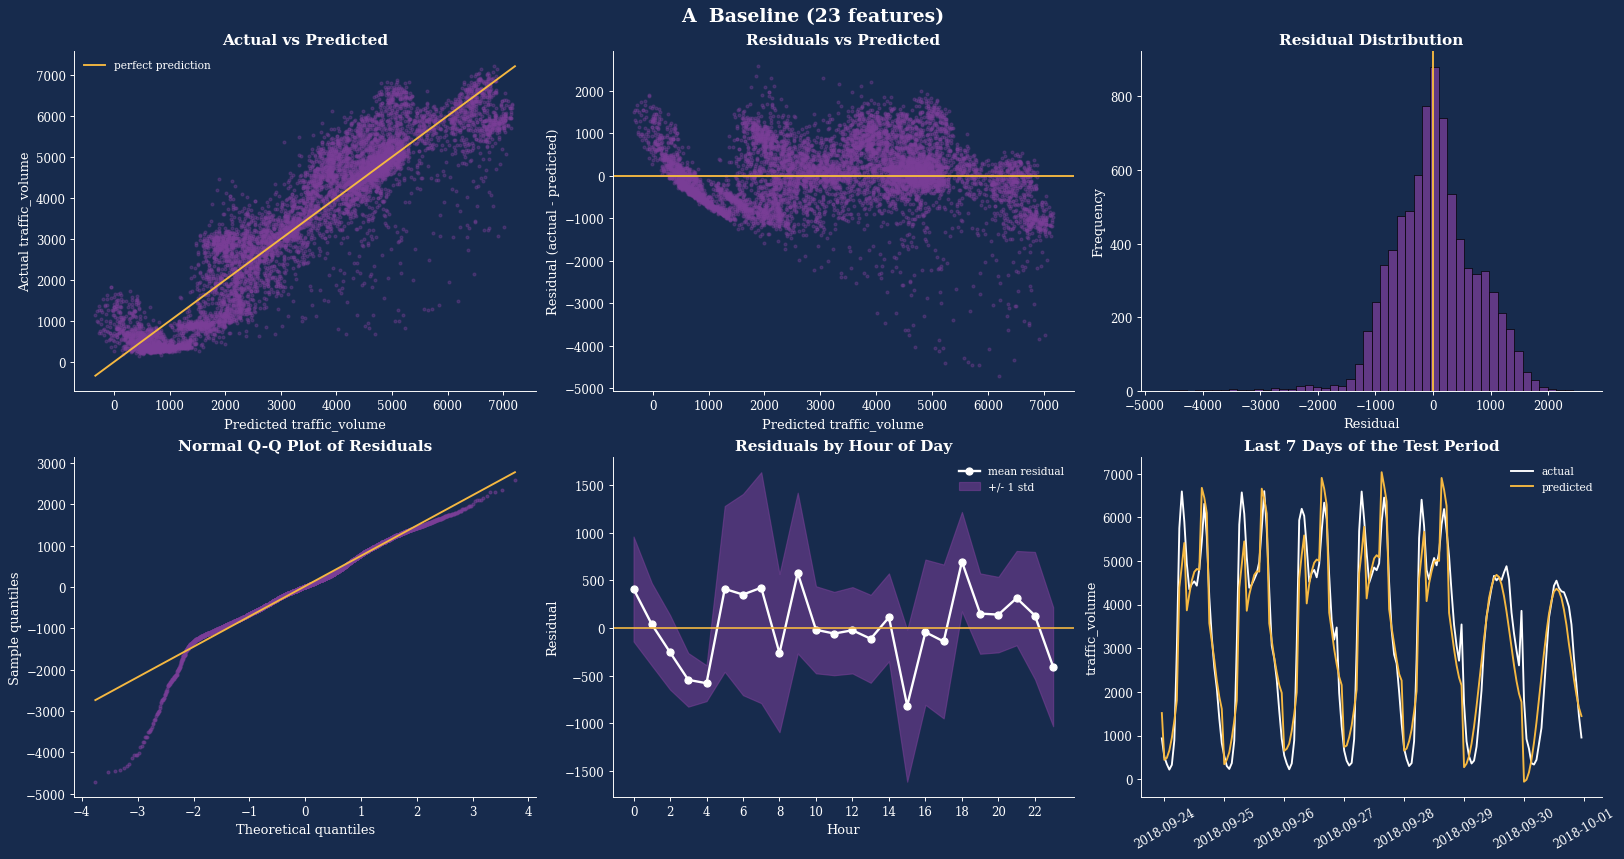

In [58]:
diagnostics(res_a)

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">5.4.3 — Coefficients</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Numeric inputs are standardized, so every bar reads &ldquo;change in vehicles/hour for a +1 standard deviation move of that input, all else equal&rdquo;; the one-hot <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">season</code> bars are differences versus the reference season. Several inputs describe the <b>same</b> thing in different forms (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour_sin</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour_cos</code>; <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">rain_1h</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">rain_1h_log1p</code> / <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_raining</code>), so their individual coefficients are not interpretable on their own; see the VIF table below.</p></div>

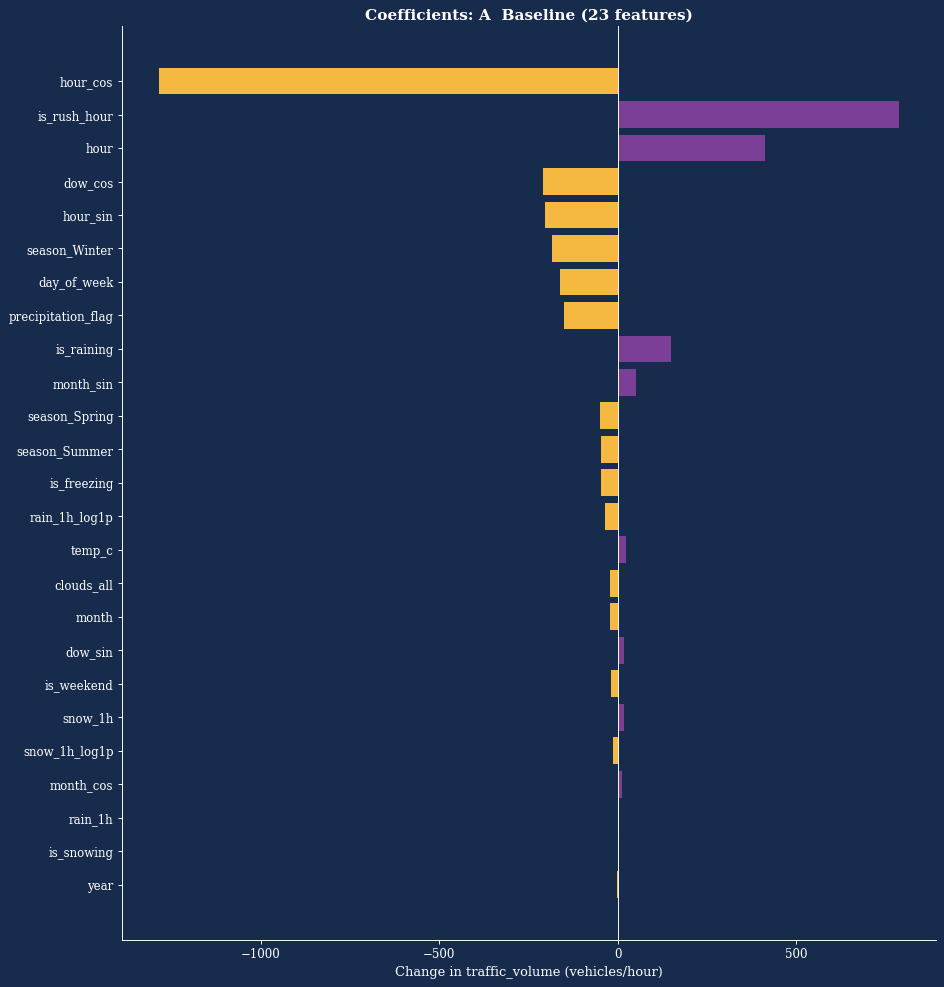

In [59]:
plot_coefficients(res_a)

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.5 — Checking the Linear-Regression Assumptions</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">OLS predictions are still usable when assumptions are violated, but <b>standard errors, p-values and coefficient signs are not</b>. Four checks on the training residuals:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>Durbin-Watson</b>: values far below 2 mean consecutive hours have correlated errors (expected for hourly traffic). The hourly series has gaps, so treat it as approximate.</li><li style="margin-bottom:4px;"><b>Breusch-Pagan</b>: a small p-value means the error variance is not constant.</li><li style="margin-bottom:4px;"><b>Skewness / kurtosis</b>: departures from normality of the residuals.</li><li style="margin-bottom:4px;"><b>VIF</b>: above ~10 means an input is largely explained by the others (multicollinearity). Perfect linear redundancy shows as <i>inf</i>.</li></ul></div>

In [60]:
summary_a, vif_a = assumption_report(res_a)
print(summary_a.to_string())
print()
vif_a.round(2).to_frame()

Durbin-Watson (2 = no autocorrelation)                 0.8457
,Breusch-Pagan LM p-value (< 0.05 = heteroscedastic)    0.0000
,residual skewness                                     -0.4596
,residual excess kurtosis                               2.4478
,


,VIF
precipitation_flag,2662.15
is_raining,2618.94
snow_1h_log1p,1175.26
snow_1h,1079.32
is_snowing,50.00
month_sin,10.56
season_Spring,10.25
month_cos,9.86
day_of_week,8.55
is_weekend,8.27


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.6 — Fixing the Model: Why the Optional Variants Follow</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">A single straight line over <b>standardized, raw-coded inputs</b> has three structural weaknesses for this data:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;">Traffic follows a <b>double-peak daily curve</b> that differs between weekdays and weekends; a model that is linear in <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code> cannot draw it.</li><li style="margin-bottom:4px;">The target is <b>right-skewed</b> and its spread grows with the level.</li><li style="margin-bottom:4px;">The set of inputs is <b>redundant</b> (raw and cyclical encodings of the same variable).</li></ul><p style="margin:0 0 8px 0;">Each variant below attacks one of these problems. Every variant is a <b>separate section that writes only to <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">RESULTS</code></b>: delete any section you do not want and the comparison in 5.8 simply skips it.</p></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.7 — Optional Variants</h3></div>

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">V1 — Cyclical Encoding Only (Remove the Redundant Raw Columns)</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Condition: drop <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">month</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">day_of_week</code> and keep only their sin/cos pairs, as recommended in 4.4.1 for linear models. This removes the most obvious collinearity.</p></div>

In [61]:
V1_DROP = ['hour', 'month', 'day_of_week']
res_v1 = run_model('V1  Cyclical encoding only', df, [c for c in NUM_COLS if c not in V1_DROP], CAT_COLS,
                   note='drops raw hour / month / day_of_week')
metrics_table([res_a, res_v1])

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
V1 Cyclical encoding only,22,32460,0.840,0.838,0.838,794.848,792.542,605.463


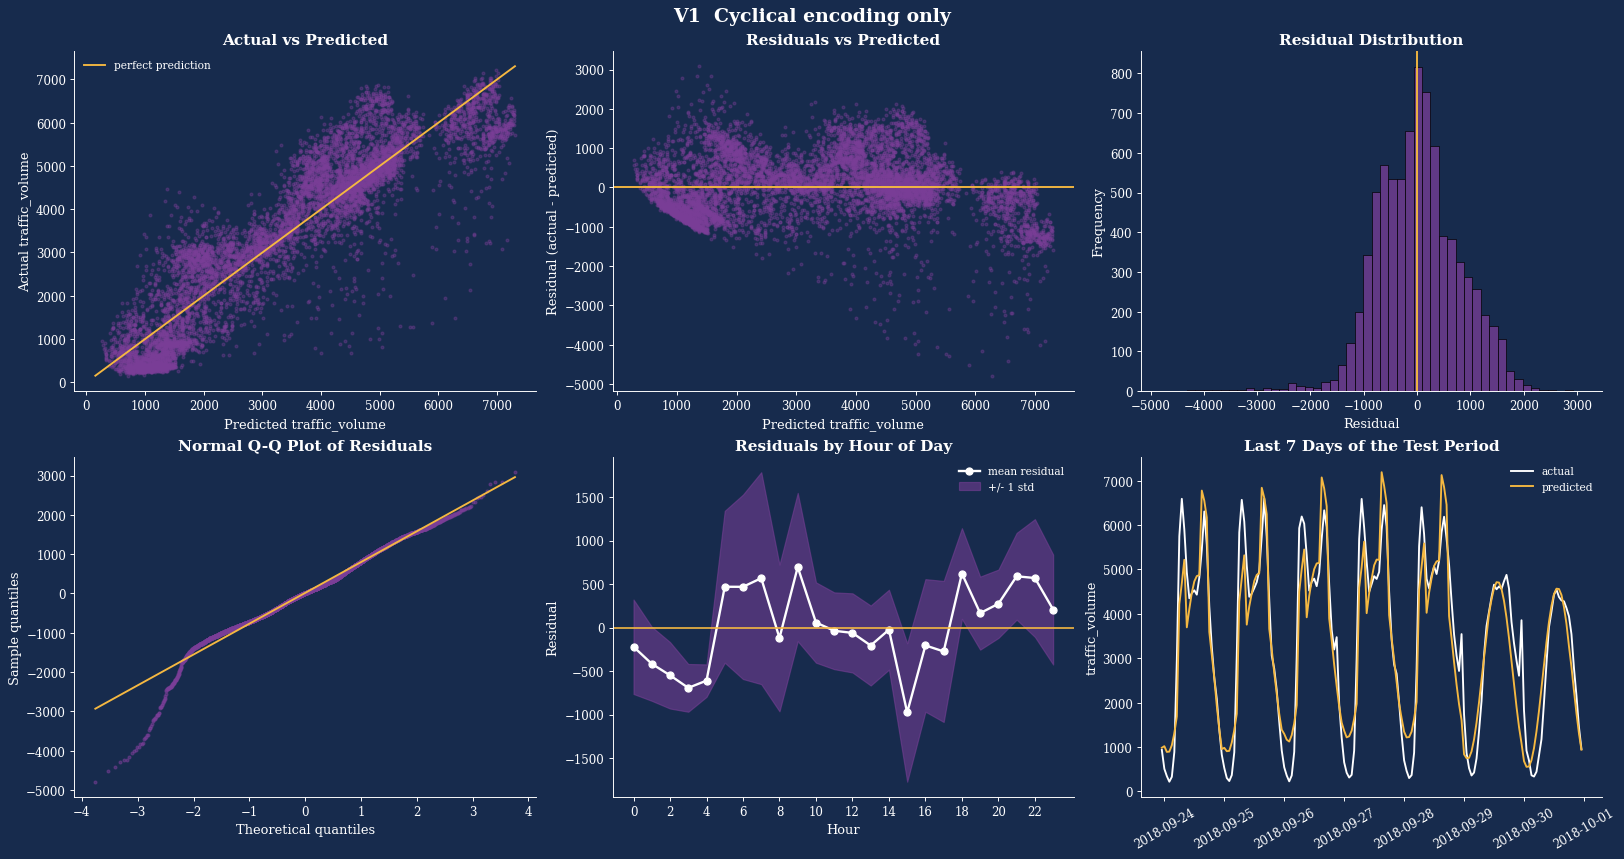

In [62]:
diagnostics(res_v1)

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">V2 — Log-Transformed Target</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Transformation: fit on <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">log1p(traffic_volume)</code> and back-transform with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">expm1</code>. All metrics below are computed back on the <b>original vehicles/hour scale</b>, so they are directly comparable with Model A. A log target turns additive effects into multiplicative ones (&ldquo;rain reduces traffic by x&nbsp;%&rdquo;) and tames the growing spread, but it can hurt when the main error comes from near-zero hours.</p></div>

In [63]:
res_v2 = run_model('V2  Log-transformed target', df, NUM_COLS, CAT_COLS, log_target=True,
                   note='fit on log1p(traffic_volume), metrics on the original scale')
metrics_table([res_a, res_v2])

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
V2 Log-transformed target,25,32460,0.631,0.620,0.619,1207.313,1213.726,832.054


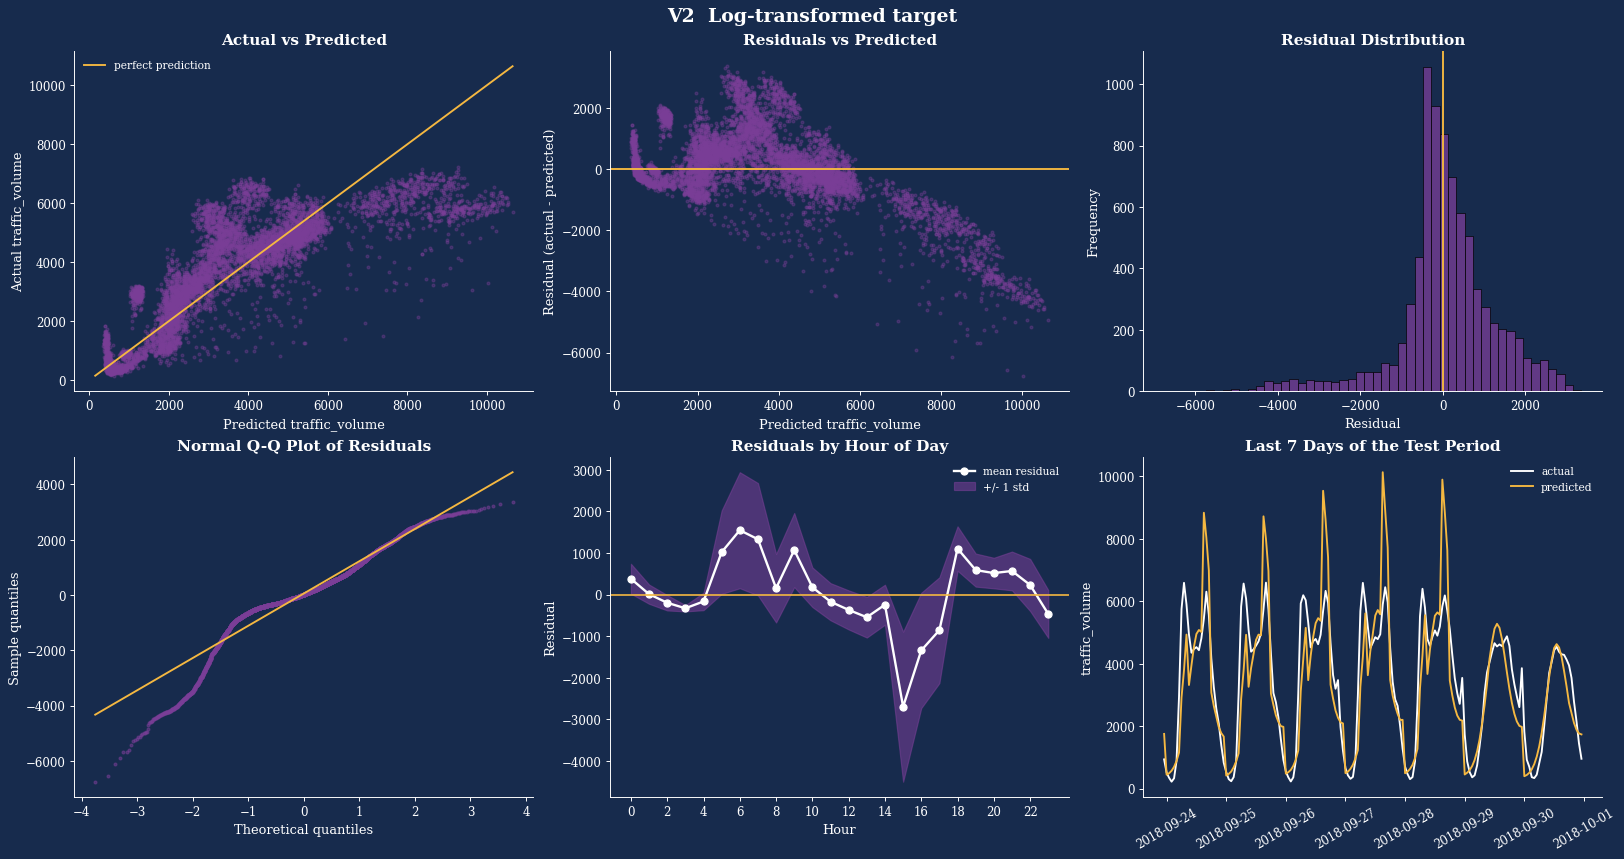

In [64]:
diagnostics(res_v2)

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">V3 — Train Without the Flagged Low-Volume Hours</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Condition: rows with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">qa_low_volume == 1</code> (fewer than 100 vehicles/h in 9 clusters: sensor outage or closure, cause unknown, see 4.2.8) are <b>removed from the training rows only</b>. The flag is used as a row filter, <b>never as an input feature</b>, and the test set is left untouched, so the score is still honest and comparable.</p></div>

In [65]:
res_v3 = run_model('V3  Train without low-volume hours', df, NUM_COLS, CAT_COLS,
                   train_filter=(df.qa_low_volume == 0),
                   note='qa_low_volume used only to drop training rows')
print('training rows removed:', len(train) - res_v3['n_train'])
metrics_table([res_a, res_v3])

training rows removed: 46


,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
V3 Train without low-volume hours,25,32414,0.860,0.857,0.857,743.740,744.576,558.860


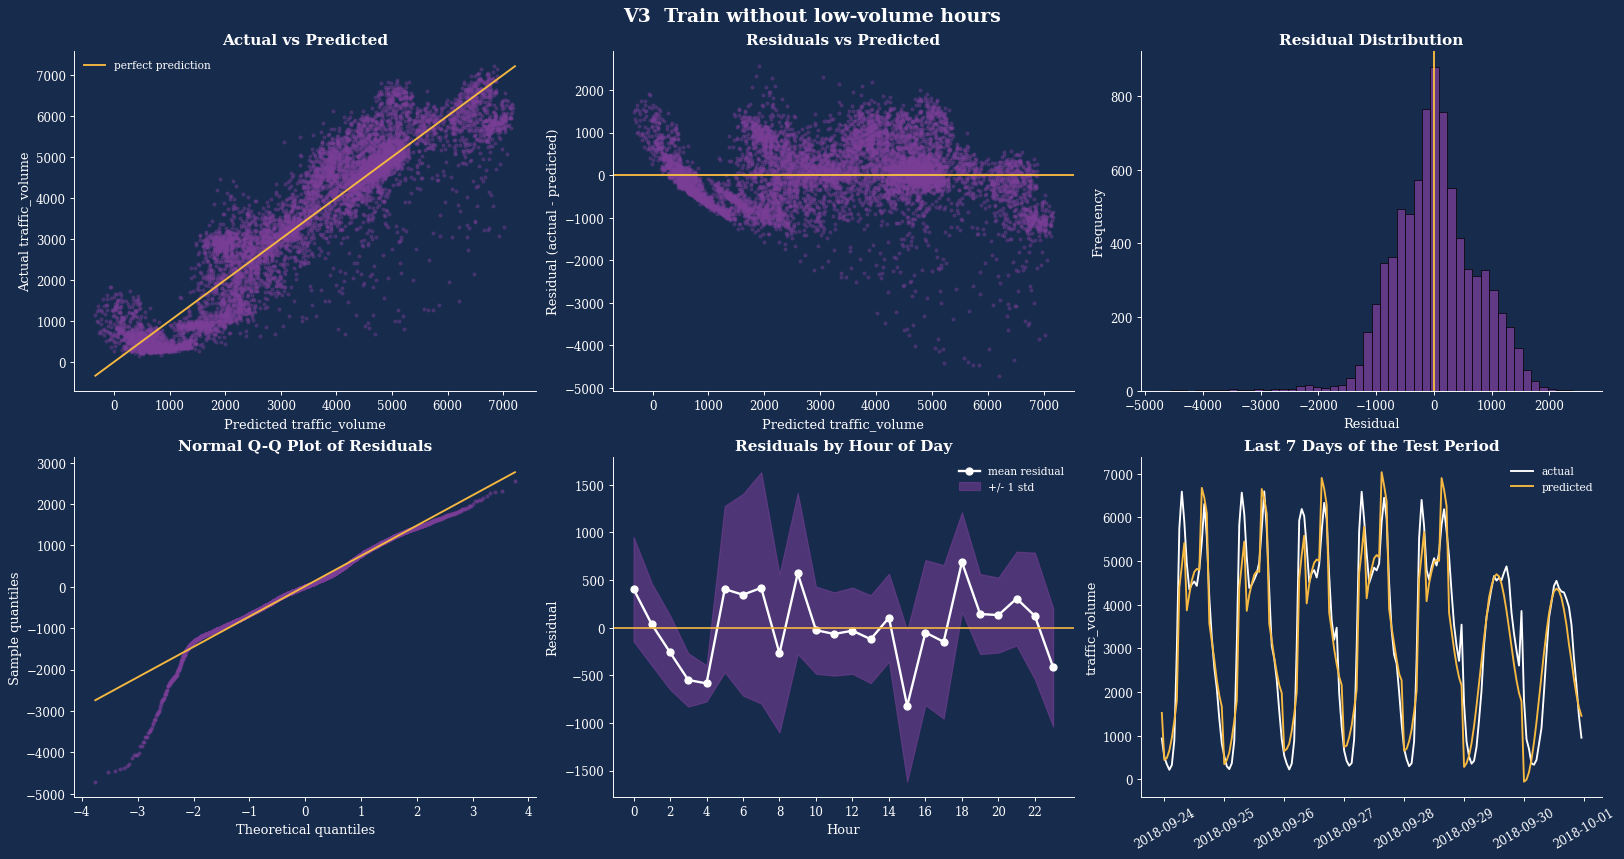

In [66]:
diagnostics(res_v3)

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">V4 — Weekday / Weekend x Hour Harmonics (Interactions)</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Transformation: add the <b>second daily harmonic</b> (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour_sin2</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">hour_cos2</code>), which lets the fitted curve have two peaks per day, and multiply the first and second harmonics by <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">is_weekend</code> so weekends get their own daily shape. This keeps the model linear in its coefficients while fixing the biggest structural error.</p></div>

In [67]:
df_v4 = df.copy()
df_v4['hour_sin2'] = np.sin(4 * np.pi * df_v4.hour / 24)
df_v4['hour_cos2'] = np.cos(4 * np.pi * df_v4.hour / 24)
V4_NEW = ['hour_sin2', 'hour_cos2']
for base in ['hour_sin', 'hour_cos', 'hour_sin2', 'hour_cos2']:
    df_v4[base + '_x_weekend'] = df_v4[base] * df_v4.is_weekend
    V4_NEW.append(base + '_x_weekend')

res_v4 = run_model('V4  Hour harmonics x weekend', df_v4, NUM_COLS + V4_NEW, CAT_COLS,
                   note='2nd harmonic + weekend interactions')
metrics_table([res_a, res_v4])

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
V4 Hour harmonics x weekend,31,32460,0.907,0.906,0.906,607.562,603.882,425.975


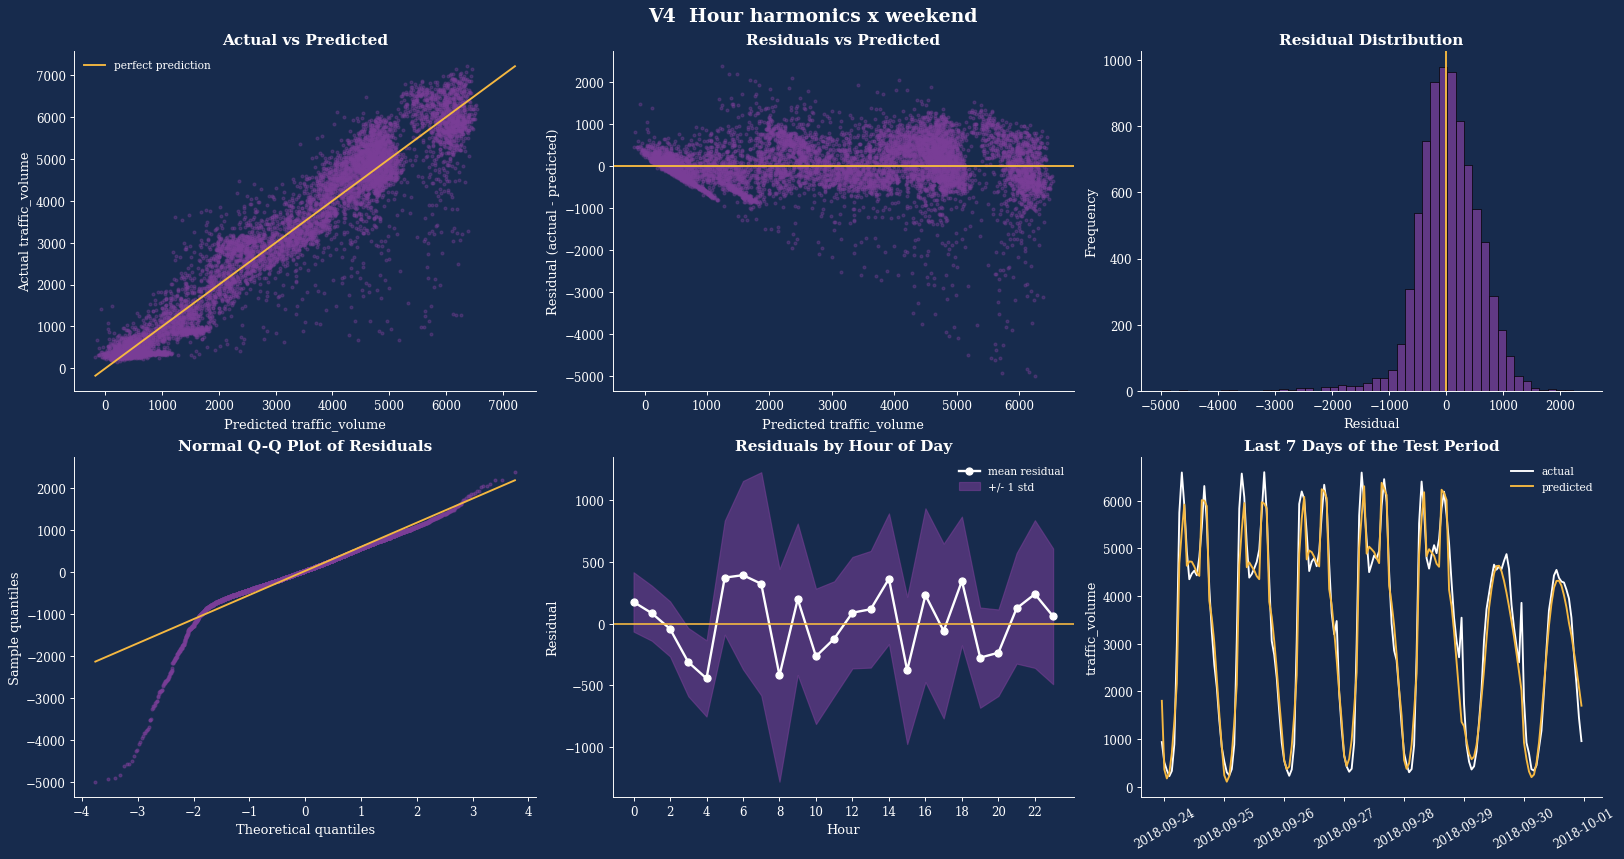

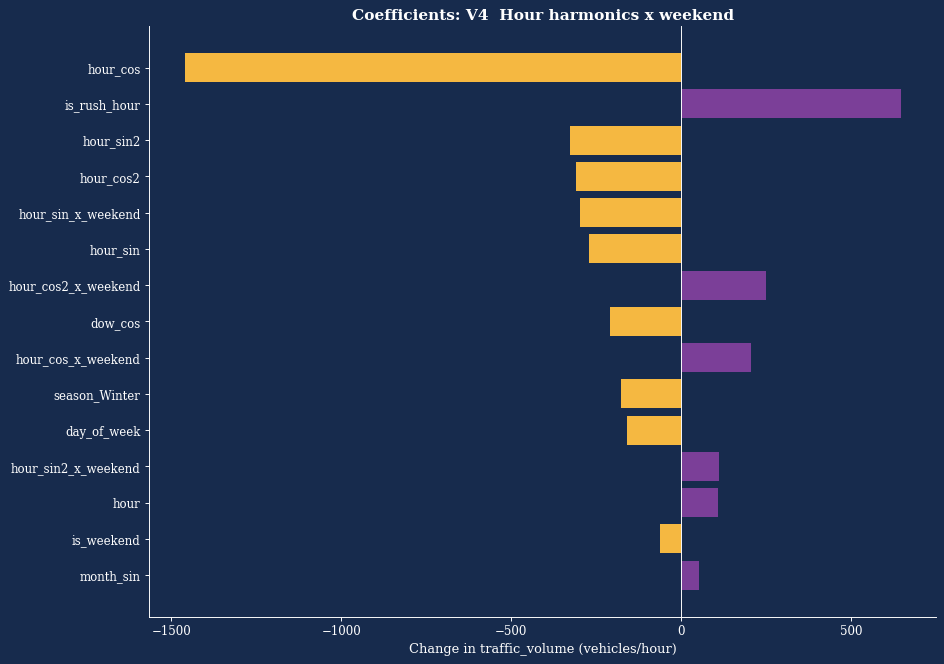

In [68]:
diagnostics(res_v4)
plot_coefficients(res_v4, top=15)

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">5.8 — Comparison of All Models</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The table and chart list every model currently stored in <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">RESULTS</code>. Lower RMSE / MAE and higher R&sup2; are better; compare the <b>test</b> columns, and look at the gap between train and test RMSE as a sign of drift over time.</p></div>

In [69]:
cmp = metrics_table(list(RESULTS.values()))
cmp

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
V1 Cyclical encoding only,22,32460,0.840,0.838,0.838,794.848,792.542,605.463
V2 Log-transformed target,25,32460,0.631,0.620,0.619,1207.313,1213.726,832.054
V3 Train without low-volume hours,25,32414,0.860,0.857,0.857,743.740,744.576,558.860
V4 Hour harmonics x weekend,31,32460,0.907,0.906,0.906,607.562,603.882,425.975


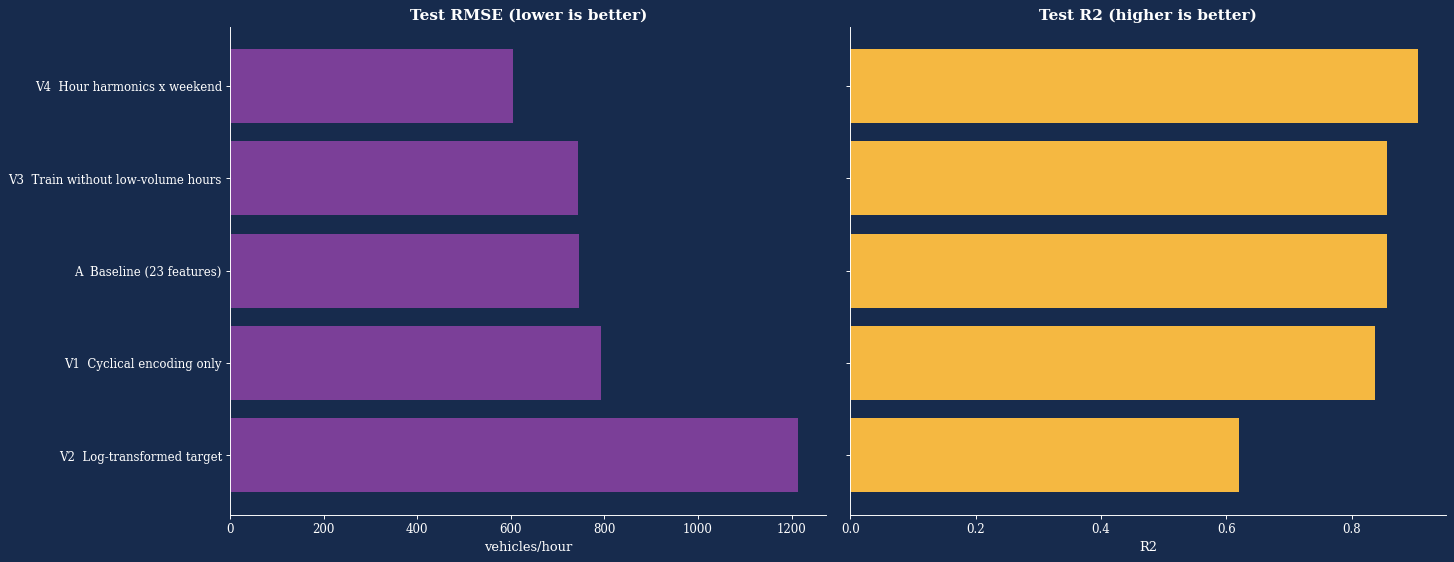

In [70]:
cmp_plot = cmp.sort_values('test RMSE', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(17, 0.7 * len(cmp_plot) + 3), facecolor=THEME_BG, constrained_layout=True)
axes[0].barh(cmp_plot.index, cmp_plot['test RMSE'], color=THEME_PURPLE)
style_axes(axes[0], 'Test RMSE (lower is better)', 'vehicles/hour')
axes[1].barh(cmp_plot.index, cmp_plot['test R2'], color=THEME_ACCENT)
style_axes(axes[1], 'Test R2 (higher is better)', 'R2')
axes[1].set_yticklabels([])
plt.show()

<br>

<a id="6"></a>
<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif;"><h2 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">Weather Groups &mdash; Does Removing the Weather Labels Matter?</h2></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">6.1 — Question and Design</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The team decided in 4.1 to exclude <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_main</code> and <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">weather_description</code> from the features. This section measures what that decision costs. The 37 descriptions are too many and too rare to use directly (some appear fewer than five times), so they are first merged into <b>groups with a similar effect on driving conditions</b>:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>Reduced_Visibility</b>: mist, fog, haze, smoke.</li><li style="margin-bottom:4px;"><b>Severe_Storm</b>: thunderstorms (including proximity thunderstorms) and squalls, i.e. strong wind and lightning.</li><li style="margin-bottom:4px;"><b>Light_Rain_Drizzle</b>, <b>Heavy_Rain</b>, <b>Snow_Ice</b>, and <b>Clear_Cloudy</b> (no driving impact, used as the reference level).</li></ul><p style="margin:0 0 8px 0;">Three models are then compared with the <b>same split and the same pipeline</b> as section 5:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b>W-A</b>: current baseline, numeric weather only (no groups).</li><li style="margin-bottom:4px;"><b>W-B</b>: W-A + the weather group (one-hot).</li><li style="margin-bottom:4px;"><b>W-C</b>: no weather information at all (context: how much does weather matter in total?).</li></ul><p style="margin:0 0 8px 0;">The difference between W-B and W-A is the answer to &ldquo;how much did removing the labels cost?&rdquo;.</p></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">6.2 — Grouping Definition</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">The dictionary below is the <b>only place to edit</b> if you disagree with a group: move a description to another list and re-run from here. A check stops the notebook if any description in the raw data is not mapped.</p></div>

In [71]:
WEATHER_GROUPS = {
    'Clear_Cloudy': ['sky is clear', 'few clouds', 'scattered clouds', 'broken clouds', 'overcast clouds'],
    'Reduced_Visibility': ['mist', 'fog', 'haze', 'smoke'],
    'Light_Rain_Drizzle': ['drizzle', 'light intensity drizzle', 'heavy intensity drizzle', 'shower drizzle',
                           'light rain', 'light intensity shower rain', 'proximity shower rain'],
    'Heavy_Rain': ['moderate rain', 'heavy intensity rain', 'very heavy rain'],
    'Snow_Ice': ['light snow', 'snow', 'heavy snow', 'shower snow', 'light shower snow',
                 'sleet', 'light rain and snow', 'freezing rain'],
    'Severe_Storm': ['thunderstorm', 'proximity thunderstorm', 'thunderstorm with light rain', 'thunderstorm with rain',
                     'thunderstorm with heavy rain', 'thunderstorm with light drizzle', 'thunderstorm with drizzle',
                     'proximity thunderstorm with rain', 'proximity thunderstorm with drizzle', 'squalls'],
}
# assumed driving-impact order, only used when WEATHER_AGG = 'worst' (see 6.3)
SEVERITY_RANK = {'Clear_Cloudy': 0, 'Reduced_Visibility': 1, 'Light_Rain_Drizzle': 2,
                 'Heavy_Rain': 3, 'Snow_Ice': 4, 'Severe_Storm': 5}
WEATHER_GROUP_MAP = {d: g for g, ds in WEATHER_GROUPS.items() for d in ds}

# same text normalisation as 4.3.2 (strip, lower-case) and the same exact-duplicate removal as the EDA section
raw_w = pd.read_csv(RAW_PATH, parse_dates=['date_time']).drop_duplicates()
raw_w['weather_main'] = raw_w['weather_main'].str.strip()
raw_w['weather_description'] = raw_w['weather_description'].str.strip().str.lower()

unmapped = sorted(set(raw_w.weather_description) - set(WEATHER_GROUP_MAP))
assert not unmapped, f'add these descriptions to WEATHER_GROUPS: {unmapped}'
print('all', raw_w.weather_description.nunique(), 'descriptions are mapped to', len(WEATHER_GROUPS), 'groups')

raw_w['weather_group'] = raw_w.weather_description.map(WEATHER_GROUP_MAP)
group_overview = (raw_w.groupby('weather_group')
                     .agg(descriptions=('weather_description', 'nunique'), reports=('weather_description', 'size'))
                     .join(pd.Series({g: ', '.join(ds) for g, ds in WEATHER_GROUPS.items()}, name='members'))
                     .loc[list(WEATHER_GROUPS)])
group_overview

all 37 descriptions are mapped to 6 groups


,descriptions,reports,members
weather_group,,,
Clear_Cloudy,5,28542,"sky is clear, few clouds, scattered clouds, br..."
Reduced_Visibility,4,8241,"mist, fog, haze, smoke"
Light_Rain_Drizzle,7,5341,"drizzle, light intensity drizzle, heavy intens..."
Heavy_Rain,3,2149,"moderate rain, heavy intensity rain, very heav..."
Snow_Ice,8,2877,"light snow, snow, heavy snow, shower snow, lig..."
Severe_Storm,10,1037,"thunderstorm, proximity thunderstorm, thunders..."


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">6.3 — One Weather Group per Hour</h3></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">Several hours have more than one weather report (5,430 timestamps, section 4.2.2). Two ways to pick the group of such an hour:</p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;"><b><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">mode</code></b> (default, consistent with 4.3.4): take the most frequent <i>(main, description)</i> pair, ties broken alphabetically, then map it to its group.</li><li style="margin-bottom:4px;"><b><code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">worst</code></b>: take the most severe group among all reports of the hour (order in <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">SEVERITY_RANK</code>).</li></ul><p style="margin:0 0 8px 0;">Both are computed and compared below so you can see how much the choice matters. Switch with <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">WEATHER_AGG</code>.</p></div>

In [72]:
WEATHER_AGG = 'mode'      # 'mode' (consistent with 4.3.4) or 'worst'

# ---- option 1: mode on the (main, description) pair, deterministic tie-break ----
pair_mode = (raw_w.groupby(['date_time', 'weather_main', 'weather_description']).size().rename('n').reset_index()
                .sort_values(['date_time', 'n', 'weather_main', 'weather_description'],
                             ascending=[True, False, True, True])
                .drop_duplicates('date_time').set_index('date_time'))
group_mode = pair_mode.weather_description.map(WEATHER_GROUP_MAP)

# ---- option 2: most severe group among the hour's reports ----
tmp = raw_w.assign(rank=raw_w.weather_group.map(SEVERITY_RANK)).sort_values(['date_time', 'rank'])
group_worst = tmp.drop_duplicates('date_time', keep='last').set_index('date_time').weather_group

agree = (group_mode == group_worst.reindex(group_mode.index)).mean()
multi = raw_w.groupby('date_time').weather_group.nunique()
print(f'hours with reports from more than one group: {(multi > 1).sum():,}')
print(f'hours where mode and worst give the same group: {agree:.1%}')

hourly_group = group_mode if WEATHER_AGG == 'mode' else group_worst
assert df.index.isin(hourly_group.index).all(), 'some hours of the clean file have no weather report'

order = list(WEATHER_GROUPS)
df['weather_group'] = pd.Categorical(hourly_group.reindex(df.index), categories=order)
assert df.weather_group.notna().all()
print('aggregation used:', WEATHER_AGG)
df.weather_group.value_counts().reindex(order).to_frame('hours')

hours with reports from more than one group: 4,069
,hours where mode and worst give the same group: 91.2%
,aggregation used: mode


,hours
weather_group,
Clear_Cloudy,28491
Reduced_Visibility,5763
Light_Rain_Drizzle,3948
Heavy_Rain,884
Snow_Ice,1250
Severe_Storm,239


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">6.3.1 — How Do the Groups Relate to Traffic?</h4></div>

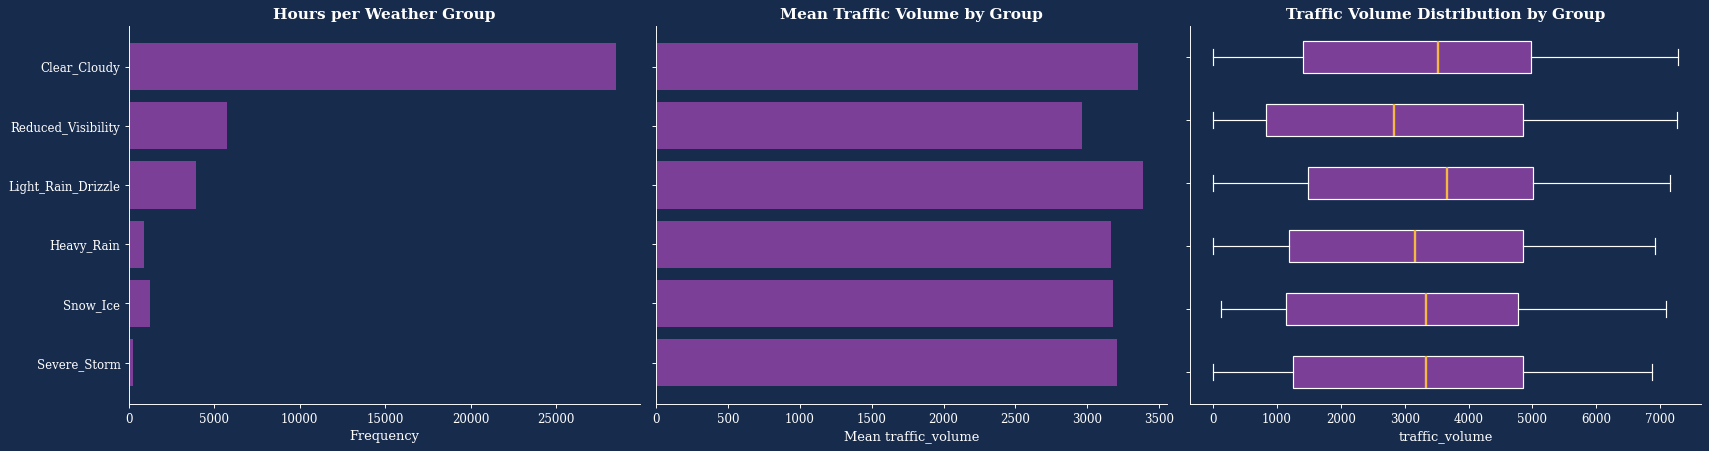

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), facecolor=THEME_BG, constrained_layout=True)

counts = df.weather_group.value_counts().reindex(order)
axes[0].barh(counts.index[::-1], counts.values[::-1], color=THEME_PURPLE)
style_axes(axes[0], 'Hours per Weather Group', 'Frequency')

means = df.groupby('weather_group', observed=True)[TARGET].mean().reindex(order)
axes[1].barh(means.index[::-1], means.values[::-1], color=THEME_PURPLE)
style_axes(axes[1], 'Mean Traffic Volume by Group', 'Mean traffic_volume')
axes[1].set_yticklabels([])

data_box = [df.loc[df.weather_group == g, TARGET].values for g in order]
bp = axes[2].boxplot(data_box, vert=False, patch_artist=True,
                     medianprops=dict(color=THEME_ACCENT, lw=2), whiskerprops=dict(color='white'),
                     capprops=dict(color='white'), flierprops=dict(markerfacecolor='white', markersize=2, alpha=0.4, markeredgecolor='none'))
for patch in bp['boxes']:
    patch.set_facecolor(THEME_PURPLE)
    patch.set_edgecolor('white')
axes[2].invert_yaxis()
style_axes(axes[2], 'Traffic Volume Distribution by Group', 'traffic_volume')
axes[2].set_yticklabels([])
plt.show()

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;"><b>Caution when reading this chart:</b> the raw group means mix in the time-of-day effect (fog and mist are frequent at night and early morning, when traffic is low). Whether the groups carry information <b>beyond</b> the calendar features is exactly what the models in 6.4 test.</p></div>

<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">6.4 — Models With and Without the Weather Groups</h3></div>

In [74]:
WEATHER_NUM = ['temp_c', 'rain_1h', 'snow_1h', 'clouds_all', 'is_freezing', 'is_raining',
               'is_snowing', 'precipitation_flag', 'rain_1h_log1p', 'snow_1h_log1p']
assert all(c in NUM_COLS for c in WEATHER_NUM)

res_w_a = run_model('W-A  numeric weather only (baseline)', df, NUM_COLS, CAT_COLS,
                    note='no weather labels')
res_w_b = run_model('W-B  numeric weather + weather groups', df, NUM_COLS, CAT_COLS + ['weather_group'],
                    note='adds one-hot weather_group (reference: Clear_Cloudy)')
res_w_c = run_model('W-C  no weather at all', df, [c for c in NUM_COLS if c not in WEATHER_NUM], CAT_COLS,
                    note='drops every weather input')
metrics_table([res_w_a, res_w_b, res_w_c])

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
W-A numeric weather only (baseline),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
W-B numeric weather + weather groups,30,32460,0.858,0.857,0.857,749.893,743.962,558.665
W-C no weather at all,15,32460,0.857,0.856,0.856,751.981,746.932,560.443


<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">6.4.1 — Cost of Removing the Groups</h4></div>

In [75]:
def nested_f_test(small, big):
    # Partial F-test on the training data: do the extra columns of `big` explain a significant extra part of the variance?
    n = small['n_train']
    rss = lambda r: float((r['resid_fit'] ** 2).sum())
    k1, k2 = small['n_features'], big['n_features']
    F = ((rss(small) - rss(big)) / (k2 - k1)) / (rss(big) / (n - k2 - 1))
    return F, stats.f.sf(F, k2 - k1, n - k2 - 1), k2 - k1


delta = pd.DataFrame({
    'W-A (without groups)': pd.Series(res_w_a['test']),
    'W-B (with groups)': pd.Series(res_w_b['test']),
})
delta['change (B - A)'] = delta['W-B (with groups)'] - delta['W-A (without groups)']
delta['relative change %'] = 100 * delta['change (B - A)'] / delta['W-A (without groups)']
print('TEST-set effect of adding the weather groups')
display(delta.round(4))

F, pval, extra = nested_f_test(res_w_a, res_w_b)
print(f'\nPartial F-test on the training data: {extra} extra columns, F = {F:.2f}, p-value = {pval:.3g}')
print('(autocorrelated residuals make this p-value optimistic: use it as a rough guide, the test-set change above is the honest number)')

TEST-set effect of adding the weather groups


,W-A (without groups),W-B (with groups),change (B - A),relative change %
R2,0.8570,0.8574,0.0003,0.0407
Adj_R2,0.8566,0.8569,0.0003,0.0305
MAE,559.2483,558.6647,-0.5836,-0.1044
RMSE,744.8724,743.9624,-0.9099,-0.1222



,Partial F-test on the training data: 5 extra columns, F = 1.22, p-value = 0.296
,(autocorrelated residuals make this p-value optimistic: use it as a rough guide, the test-set change above is the honest number)


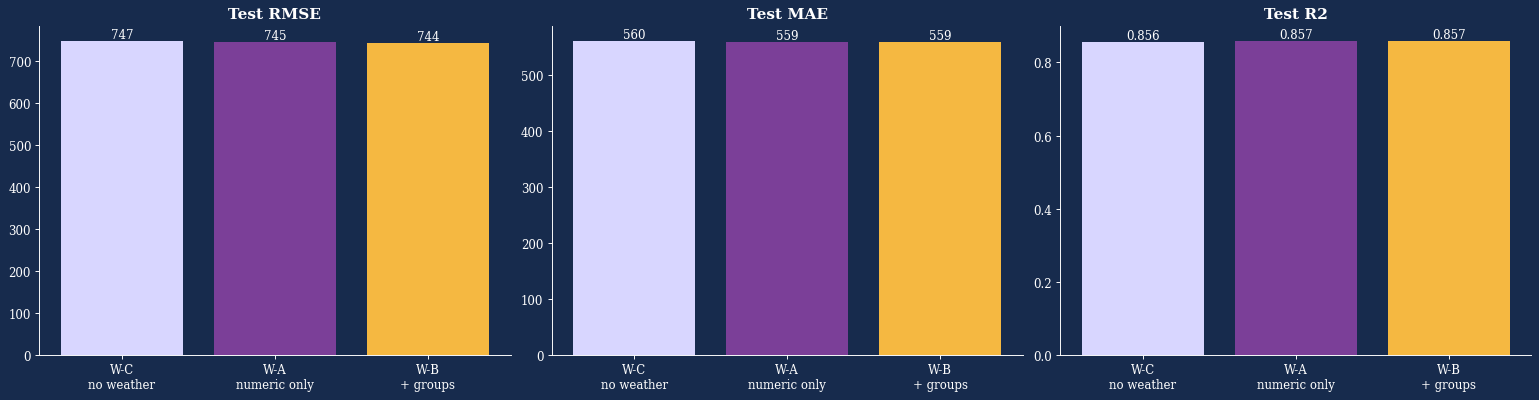

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), facecolor=THEME_BG, constrained_layout=True)
names = ['W-C\nno weather', 'W-A\nnumeric only', 'W-B\n+ groups']
rs = [res_w_c, res_w_a, res_w_b]
for ax, key, title in zip(axes, ['RMSE', 'MAE', 'R2'], ['Test RMSE', 'Test MAE', 'Test R2']):
    vals = [r['test'][key] for r in rs]
    ax.bar(names, vals, color=[THEME_LAVENDER, THEME_PURPLE, THEME_ACCENT])
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:,.3f}' if key == 'R2' else f'{v:,.0f}', ha='center', va='bottom', color='white', fontfamily='serif', fontsize=10)
    style_axes(ax, title)
plt.show()

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">6.4.2 — Effect Size of Each Group (Coefficients With Standard Errors)</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">One-hot columns are <b>not</b> standardized, so each coefficient reads directly as <b>vehicles per hour compared with Clear_Cloudy</b>, holding all other inputs fixed. Bars are &plusmn;1.96 standard errors; because consecutive hours are correlated these intervals are too narrow, so only trust clear separations from zero.</p></div>

,coef,se,t
Heavy_Rain,-21.09,32.31,-0.65
Light_Rain_Drizzle,4.15,16.76,0.25
Reduced_Visibility,-26.50,13.28,-2.00
Severe_Storm,-8.39,59.29,-0.14
Snow_Ice,24.57,26.96,0.91


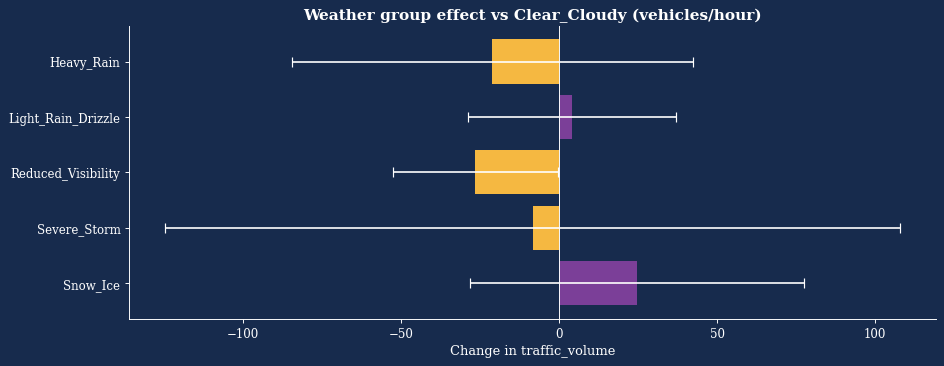

In [77]:
def coef_table(res):
    X = res['X_tr']
    A = np.column_stack([np.ones(len(X)), X.values])
    lr = res['pipe'].named_steps['lr']
    b = np.r_[lr.intercept_, lr.coef_]
    e = res['resid_fit'].values
    sigma2 = (e ** 2).sum() / (len(A) - A.shape[1])
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(A.T @ A)))
    return pd.DataFrame({'coef': b, 'se': se, 't': b / se}, index=['intercept'] + list(X.columns))


ct = coef_table(res_w_b)
grp = ct[ct.index.str.startswith('weather_group_')].copy()
grp.index = grp.index.str.replace('weather_group_', '', regex=False)
display(grp.round(2))

fig, ax = plt.subplots(figsize=(11, 4.2), facecolor=THEME_BG, constrained_layout=True)
ypos = np.arange(len(grp))
ax.barh(ypos, grp.coef, xerr=1.96 * grp.se, color=[THEME_PURPLE if v >= 0 else THEME_ACCENT for v in grp.coef],
        error_kw=dict(ecolor='white', lw=1.4, capsize=4))
ax.set_yticks(ypos)
ax.set_yticklabels(grp.index)
ax.axvline(0, color='white', lw=0.8)
ax.invert_yaxis()
style_axes(ax, 'Weather group effect vs Clear_Cloudy (vehicles/hour)', 'Change in traffic_volume')
plt.show()

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">6.4.3 — Where Do the Groups Help? (Test Residuals by Group)</h4></div>

<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;">If a group is systematically mis-predicted by W-A, its mean residual (<b>bias</b>) is far from zero; W-B should pull it back towards zero. Groups with few test hours give noisy numbers: read the <i>hours</i> column.</p></div>

,hours (test),W-A bias,W-A RMSE,W-B bias,W-B RMSE
weather_group,,,,,
Clear_Cloudy,5392,48.5,714.7,46.7,714.6
Reduced_Visibility,1386,-114.5,885.2,-91.6,882.0
Light_Rain_Drizzle,745,-3.8,707.3,-11.2,707.2
Heavy_Rain,162,90.4,665.7,104.3,665.9
Snow_Ice,354,149.9,696.6,122.9,691.1
Severe_Storm,76,-1.4,780.8,4.3,780.9


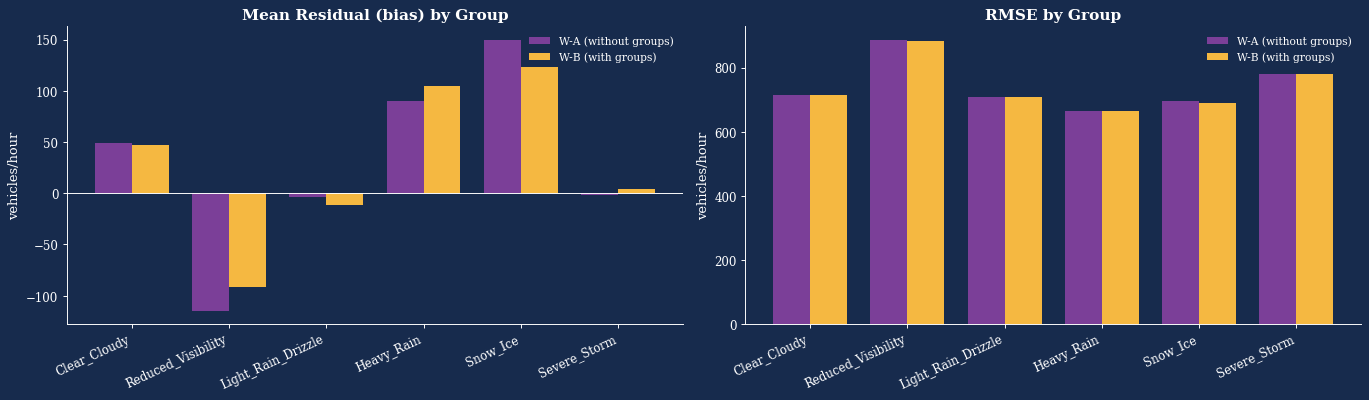

In [78]:
te_group = df['weather_group'].iloc[split_idx:]
rows = {}
for tag, r in [('W-A', res_w_a), ('W-B', res_w_b)]:
    resid = r['y_te'] - r['yhat_te']
    g = resid.groupby(te_group, observed=True)
    rows[tag + ' bias'] = g.mean()
    rows[tag + ' RMSE'] = g.apply(lambda s: float(np.sqrt((s ** 2).mean())))
by_group = pd.DataFrame(rows).reindex(order)
by_group.insert(0, 'hours (test)', te_group.value_counts().reindex(order).fillna(0).astype(int))
display(by_group.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6), facecolor=THEME_BG, constrained_layout=True)
x = np.arange(len(order)); w = 0.38
for ax, suffix, title in zip(axes, ['bias', 'RMSE'], ['Mean Residual (bias) by Group', 'RMSE by Group']):
    ax.bar(x - w / 2, by_group['W-A ' + suffix], w, color=THEME_PURPLE, label='W-A (without groups)')
    ax.bar(x + w / 2, by_group['W-B ' + suffix], w, color=THEME_ACCENT, label='W-B (with groups)')
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=25, ha='right')
    if suffix == 'bias':
        ax.axhline(0, color='white', lw=0.8)
    style_axes(ax, title, None, 'vehicles/hour')
    style_legend(ax)
plt.show()

<div style="border-left:5px solid #4B3F8F; background:#eef2f7; padding:8px 14px; border-radius:6px; margin:20px 0 8px 0; direction:ltr; text-align:left;"><h4 style="margin:0; color:#1e3a5f; font-family:'Georgia', 'Times New Roman', serif;">6.4.4 — Optional: Compare the Two Hourly-Label Rules</h4></div>

In [79]:
alt_series = group_worst if WEATHER_AGG == 'mode' else group_mode
alt_name = 'worst' if WEATHER_AGG == 'mode' else 'mode'
df_alt = df.copy()
df_alt['weather_group'] = pd.Categorical(alt_series.reindex(df_alt.index), categories=order)
res_w_b_alt = run_model(f'W-B  groups via "{alt_name}" rule', df_alt, NUM_COLS, CAT_COLS + ['weather_group'])
metrics_table([res_w_a, res_w_b, res_w_b_alt])

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
W-A numeric weather only (baseline),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
W-B numeric weather + weather groups,30,32460,0.858,0.857,0.857,749.893,743.962,558.665
"W-B groups via ""worst"" rule",30,32460,0.858,0.858,0.858,749.314,741.678,557.648


<div style="text-align: center; background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F); padding: 10px 15px; border-radius: 10px; box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35); font-family: 'Segoe UI', sans-serif; margin: 26px 0 12px 0;"><h3 style="color: #D8D6FF; font-family: 'Georgia', serif; font-weight: bold; margin: 0; letter-spacing: 1px;">6.5 — Overall Comparison</h3></div>

In [80]:
metrics_table(list(RESULTS.values()))

,n_features,n_train,train R2,test R2,test adj R2,train RMSE,test RMSE,test MAE
model,,,,,,,,
A Baseline (23 features),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
V1 Cyclical encoding only,22,32460,0.840,0.838,0.838,794.848,792.542,605.463
V2 Log-transformed target,25,32460,0.631,0.620,0.619,1207.313,1213.726,832.054
V3 Train without low-volume hours,25,32414,0.860,0.857,0.857,743.740,744.576,558.860
V4 Hour harmonics x weekend,31,32460,0.907,0.906,0.906,607.562,603.882,425.975
W-A numeric weather only (baseline),25,32460,0.858,0.857,0.857,749.963,744.872,559.248
W-B numeric weather + weather groups,30,32460,0.858,0.857,0.857,749.893,743.962,558.665
W-C no weather at all,15,32460,0.857,0.856,0.856,751.981,746.932,560.443
"W-B groups via ""worst"" rule",30,32460,0.858,0.858,0.858,749.314,741.678,557.648


<div style="background:#eef2f7; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; margin:10px 0 16px 0; box-shadow:0 2px 6px rgba(0,0,0,0.08); font-family:'Segoe UI', sans-serif; color:#1f2937; direction:ltr; text-align:left; line-height:1.55;"><p style="margin:0 0 8px 0;"><b>How to read the result:</b></p><ul style="margin:4px 0 8px 22px; padding:0;"><li style="margin-bottom:4px;">If W-B&rsquo;s <b>test RMSE / R&sup2;</b> is practically the same as W-A&rsquo;s, the weather groups add little beyond the numeric weather and the calendar features, which supports the team decision to leave the labels out.</li><li style="margin-bottom:4px;">If W-B is clearly better, and the gain is concentrated in groups such as Reduced_Visibility or Severe_Storm (6.4.3), the labels carry information the numbers (<code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">rain_1h</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">snow_1h</code>, <code style="background:#dfe6f0; color:#1e3a5f; padding:1px 6px; border-radius:4px; font-size:0.92em;">clouds_all</code>) do not, and the decision deserves a second look.</li><li style="margin-bottom:4px;">W-C shows how much weather matters in total. If W-C is close to W-A, weather is a minor driver of hourly traffic compared with hour and weekday, and no weather encoding will change the picture much.</li><li style="margin-bottom:4px;">A linear model cannot express weather <i>x</i> rush-hour interactions (fog matters more at 7&nbsp;am than at 3&nbsp;am). A small gain here does not rule out a larger one for a tree-based model.</li></ul></div>